### TokaMaker Example: Equilibrium reconstruction in DIII-D with Scape-Off Layer Current {#doc_tMaker_DIIID_ex4}
==========
In this example we show how to perform an equilibrium reconstruction in DIII-D using real data from a gEQDSK file, a k-file and a MHDIn.dat file. We also utilize the scrape-off layer functionality to model current outside the LCFS.

**Warning:** The reconstruction functionality in TokaMaker is still a work in progress, as the PSI-Tri capabilities are activated and tested. Please use with care.

In [1]:
import os
import sys
import json
import random
from collections import OrderedDict
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Load TokaMaker library

To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

For meshing we will use the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain "gs_Domain" class to build a 2D triangular grid suitable for Grad-Shafranov equilibria. This class uses the [triangle code](https://www.cs.cmu.edu/~quake/triangle.html) through a [python wrapper](https://pypi.org/project/triangle/).

In [2]:
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
print(tokamaker_python_path)
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.reconstruction import reconstruction
from OpenFUSIONToolkit.TokaMaker.util import read_eqdsk, read_mhdin, read_kfile

/Users/johnl/Desktop/OpenFUSIONToolkit-SOL-Currents


## Initialize TokaMaker object
We now create a \ref OpenFUSIONToolkit.OFT_env "OFT_env" instance for execution using two threads and a \ref OpenFUSIONToolkit.TokaMaker.TokaMaker "TokaMaker" instance to use for equilibrium calculations. Note at present only a single `TokaMaker` instance can be used per python kernel, so this command should only be called **once** in a given Jupyter notebook or python script. In the future this restriction may be relaxed.

In [3]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    Add-FSOL
Revision id:           5528671f
Parallelization Info:
  Not compiled with MPI


python(36847) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(36848) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(36849) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(36850) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  # of OpenMP threads =    2
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------



## Load Info from gEQDSK File and MHDIn.Dat


In [4]:
shot_tag = '195040.03000'

eqdsk = read_eqdsk('g'+shot_tag)
# https://iopscience.iop.org/article/10.1088/1361-6587/ade6a8/pdf

e_coil_names = ['ECOILA','ECOILB','E567UP','E567DN','E89DN','E89UP']
f_coil_names = ['F1A', 'F2A', 'F3A', 'F4A', 'F5A', 'F6A', 'F7A', 'F8A', 'F9A', 'F1B', 'F2B', 'F3B', 'F4B', 'F5B', 'F6B', 'F7B', 'F8B', 'F9B']

machine_dict, _ = read_mhdin('mhdin040620.dat', e_coil_names, f_coil_names)

### Setup Mesh

In [5]:
mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh('DIIID_mesh_195040.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.setup(order = 2, F0 = -5.3*6.2)


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.574E+01
    # of points  =    9191
    # of edges   =   27410
    # of cells   =   18220
    # of boundary points =     160
    # of boundary edges  =     160
    # of boundary cells  =     160
  Resolution statistics:
    hmin =  3.159E-04
    hrms =  4.755E-02
    hmax =  1.540E-01
  Surface grounded at vertex    1789


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    2.7669999999999999E-003
Creating EQ object


## Update GS Settings

In [6]:
# mygs.settings.sol_currents = True
mygs.update_settings()

## Define vertical stability coils

In [7]:
vsc_signs = {key: 0 for key in mygs.coil_sets}
vsc_signs['F9A'] = 1.0
vsc_signs['F9B'] = -1.0
mygs.set_coil_vsc(vsc_signs)

## Perform Reconstruction

### Create Reconstruction Object

In [8]:
myrecon = reconstruction(mygs)

### Load Sensor Locations From Files

In [9]:
mag_sensors = machine_dict['PROBE']
flux_loops = machine_dict['LOOP']

### Plot probe locations

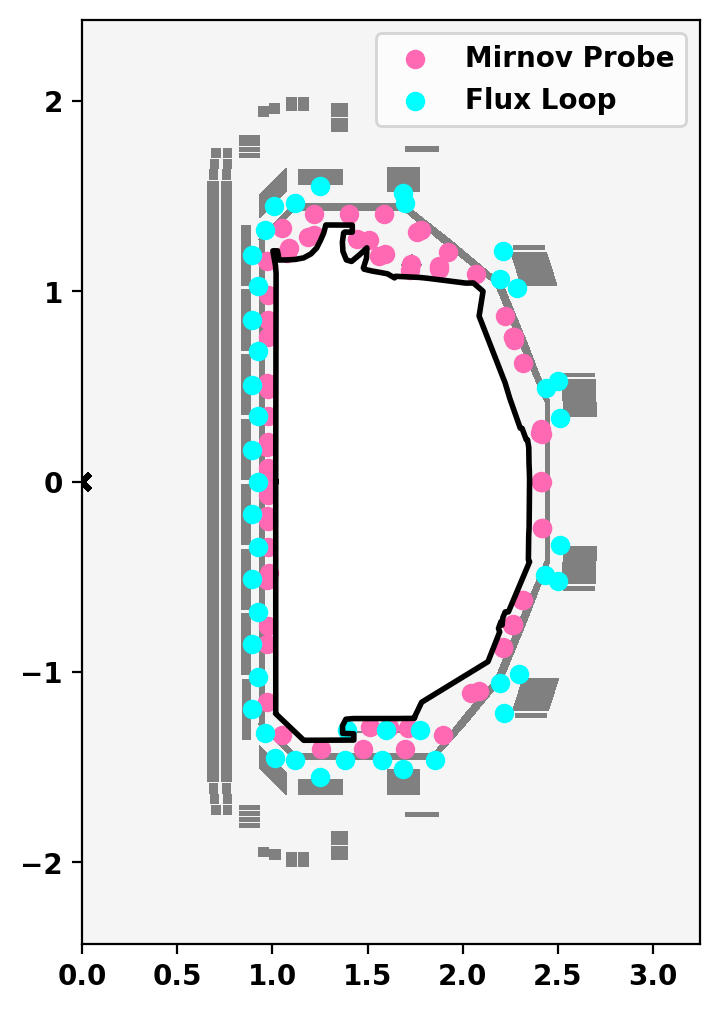

In [10]:
fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,limiter_color='k')
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5)
mygs.plot_constraints(fig, ax)

def plot_sensors(sensors, label, color):
    r_coords = [s[0] for _,s in sensors.items()]
    z_coords = [s[1] for _,s in sensors.items()]
    ax.scatter(x=r_coords, y=z_coords, label=label, color=color)

plot_sensors(mag_sensors, label="Mirnov Probe", color='hotpink')
plot_sensors(flux_loops, label="Flux Loop", color='cyan')

ax.legend()
plt.show()

### Load Shot Data from DIII-D
Here we load data from a DIII-D k file representing a shot at a given point in time.

In [11]:
probes_dict, loops_dict, e_coil_dict, f_coil_dict, _ = read_kfile('k'+shot_tag, machine_dict, e_coil_names, f_coil_names)

### Read Data From DIII-D to Mirnov Probes

In [12]:
def convert_Mirnov_coordinates(sensor):
    R, z, angle = sensor
    position = np.array([R, z])

    angle_rads = angle * np.pi / 180
    orientation = np.array([np.cos(angle_rads), 0, np.sin(angle_rads)])
    return position, orientation

B_vals = [probes_dict[key][0] for key in mag_sensors if key in probes_dict]
B_mean = np.mean(np.positive(B_vals))
mirnov_names = []

for key, mag in mag_sensors.items():
    if probes_dict[key][1] == 0:
        print("{} not selected.".format(key))
        continue
    position, orientation = convert_Mirnov_coordinates(mag)
    mirnov_names.append(key)
    B_meas, _ = probes_dict[key]
    myrecon.add_Mirnov(position, orientation, B_meas, err=0.1*max(B_mean, abs(B_meas)))


MPI66M247 not selected.
MPI79A147 not selected.
MPI6NA132 not selected.
DSL3U180 not selected.
MPI5U157 not selected.
DSL6U157 not selected.
MPI3L180 not selected.


### Read Data From Equilibrium to Flux Loops

In [ ]:
flux_locs = []
flux_vals = []

psi_vals = [loops_dict[key][0] for key in flux_loops if key in loops_dict]
psi_mean = np.mean(np.positive(psi_vals))

flux_names = []

for key, fl in flux_loops.items():
    if loops_dict[key][1] == 0:
        print("{} not selected.".format(key))
        continue
    flux_names.append(key)
    B_tmp, _ = loops_dict[key]
    flux_locs.append(fl)
    flux_vals.append(B_tmp)
    psi_val = B_tmp*2.0*np.pi
    myrecon.add_flux_loop(fl, psi_val, err=0.1*(max(psi_mean, abs(psi_val))))

mygs.set_flux(np.array(flux_locs), np.array(flux_vals), weights=1e4*np.ones_like(flux_vals))

PSF3A not selected.
PSF7NA not selected.
PSI34A not selected.
PSF6FB not selected.
PSI89FB not selected.
PSI2L not selected.


/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_36844/2041771722.py:20: DeprecationWarning: `set_flux()` is deprecated, use `set_psi_constraints()` instead. This function will be removed in a future version.
  mygs.set_flux(np.array(flux_locs), np.array(flux_vals), weights=1e3*np.ones_like(flux_vals))


## Profiles

Defined using experimental profiles + paramterized bump function. See King et al. (2017).

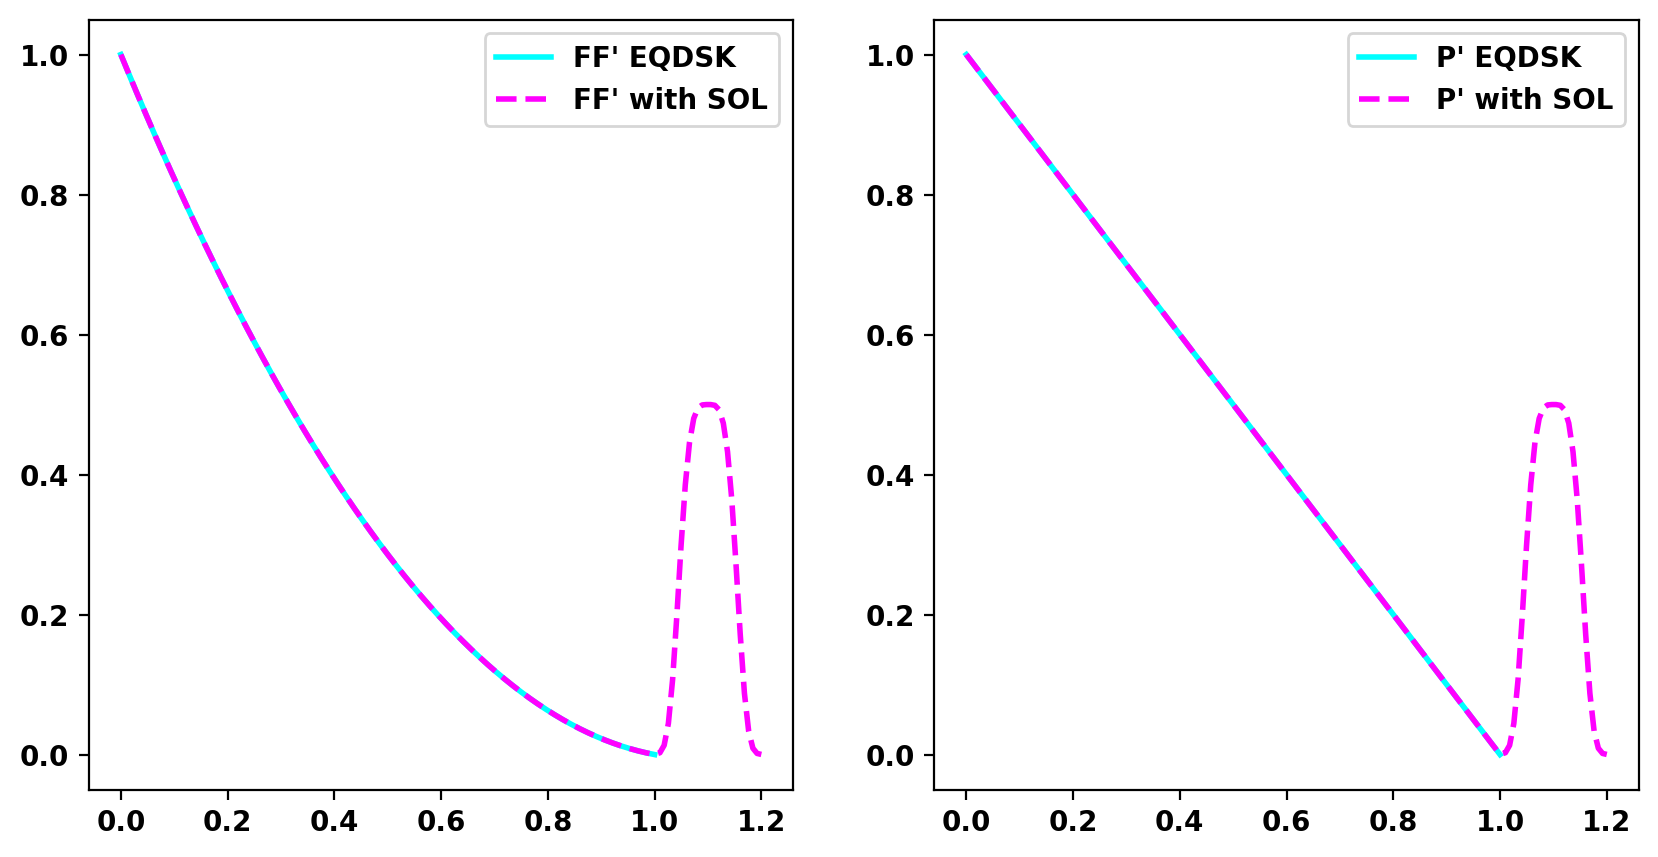

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
ffprim = eqdsk['ffprim']
pprime = eqdsk['pprime']
x = np.linspace(0.0, 1.0, len(ffprim))

ffprim -= ffprim[-1]
ffprim = ffprim / ffprim[0]

pprime -= pprime[-1]
pprime = pprime / pprime[0]

ax[0].plot(x, ffprim, label='FF\' EQDSK', color='cyan')
ax[1].plot(x, pprime, label='P\' EQDSK', color='cyan')

x_sol = np.linspace(1.01, 1.2, 25)
x = np.append(x, x_sol)
pprime = np.append(pprime, len(x_sol) * [0.0])
ffprim = np.append(ffprim, len(x_sol) * [0.0]) 

def supergaussian(psi_n, centr, std=0.05):
    return np.exp(-(psi_n - centr) ** 4 / (2 * std**4))

ffp_bump = 0.5 * supergaussian(x, 1.1, std=0.05)
ffprim += ffp_bump

pp_bump = 0.5 * supergaussian(x, 1.1, std=0.05)
pprime += pp_bump

ax[0].plot(x, ffprim, label='FF\' with SOL', linestyle='--', color='magenta')
ax[1].plot(x, pprime, label='P\' with SOL', linestyle='--', color='magenta')

ax[0].legend()
ax[1].legend()
plt.show()

mygs.set_profiles(ffp_prof={'type': 'linterp', 'y': ffprim, 'x': x},pp_prof={'type': 'linterp', 'y': pprime, 'x': x}, f_SOL=True)


## Compute starting equilibrium

In [15]:
##### Add plasma current and flux loop constraints
Ip_target=abs(eqdsk['ip'])
P0_target=eqdsk['pres'][0]
mygs.set_targets(Ip=Ip_target, pax=P0_target)

target_currents = {}
target_errs = {}

for key in e_coil_dict:
    if e_coil_dict[key][1] == 0:
        continue
    target_currents[key] = e_coil_dict[key][0]
    target_errs[key] = abs(e_coil_dict[key][1])

for key in f_coil_dict:
    if f_coil_dict[key][1] == 0:
        continue
    target_currents[key] = f_coil_dict[key][0] / machine_dict['FCOIL'][key][4]
    target_errs[key] = abs(f_coil_dict[key][1] / machine_dict['FCOIL'][key][4])

# Set coil regularization to weakly track measured coil currents
regularization_terms = []
for key in e_coil_dict:
    if e_coil_dict[key][1] == 0:
        continue
    regularization_terms.append(mygs.coil_reg_term({key: 1.0},
                                                   target=target_currents[key],
                                                   weight=1.0E1))
for key in f_coil_dict:
    if f_coil_dict[key][1] == 0:
            continue
    regularization_terms.append(mygs.coil_reg_term({key: 1.0},
                                                   target=target_currents[key],
                                                   weight=1.0E2))

# Set zero target current and small weight on virtual VSC to allow up-down adjustment
regularization_terms.append(mygs.coil_reg_term({'#VSC': 1.0},target=0.0,weight=1.E-2))

# Pass regularization terms to TokaMaker
mygs.set_coil_reg(reg_terms=regularization_terms)

# Initial equilibrium with very rough guess
R0 = eqdsk['rcentr']
Z0 = 0.0
a = 0.6
kappa = 1.13
delta = .1

err_flag = mygs.init_psi(R0, Z0, a, kappa, delta)

# Compute initial equilibrium
mygs.settings.maxits=1000
mygs.update_settings()
mygs.solve()

Starting non-linear GS solver
     1 -2.7883E+00  1.2507E+00  5.2352E-03  1.7566E+00 -7.8813E-03 -3.7244E+01
     2 -2.1422E+00  1.1917E+00  2.6048E-03  1.7613E+00 -9.9883E-03 -5.7372E+01
     3 -1.9228E+00  1.1903E+00  1.7028E-03  1.7597E+00 -1.1950E-02 -7.3087E+01
     4 -1.8091E+00  1.1968E+00  1.1930E-03  1.7567E+00 -1.3795E-02 -8.3939E+01
     5 -1.7307E+00  1.2019E+00  8.6891E-04  1.7537E+00 -1.5559E-02 -9.2038E+01
     6 -1.6779E+00  1.2063E+00  6.4962E-04  1.7510E+00 -1.7271E-02 -9.8134E+01
     7 -1.6412E+00  1.2101E+00  4.9093E-04  1.7486E+00 -1.8929E-02 -1.0259E+02
     8 -1.6141E+00  1.2130E+00  3.7756E-04  1.7467E+00 -2.0536E-02 -1.0581E+02
     9 -1.5943E+00  1.2152E+00  2.9660E-04  1.7451E+00 -2.2096E-02 -1.0806E+02
    10 -1.5798E+00  1.2168E+00  2.3842E-04  1.7438E+00 -2.3575E-02 -1.0958E+02
    11 -1.5691E+00  1.2181E+00  1.9779E-04  1.7427E+00 -2.5092E-02 -1.1056E+02
    12 -1.5613E+00  1.2190E+00  1.6850E-04  1.7419E+00 -2.6556E-02 -1.1112E+02
    13 -1.5556E+00  1.

## Plot starting equilibrium

Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    8.1012E+05
  Current Centroid [m]    =    1.688 -0.130
  Magnetic Axis [m]       =    1.738 -0.122
  Elongation              =    1.492 (U:  1.353, L:  1.632)
  Triangularity           =    0.334 (U:  0.112, L:  0.557)
  Plasma Volume [m^3]     =   15.069
  q_0, q_95               =   -13.626 -50.521
  Plasma Pressure [Pa]    =   Axis:  1.0486E+05, Peak:  1.0486E+05
  Stored Energy [J]       =    7.8095E+05
  <Beta_pol> [%]          =   177.6962
  <Beta_tor> [%]          =    0.0208
  <Beta_n>   [%]          =    0.3099
  Diamagnetic flux [Wb]   =    4.4433E-04
  Toroidal flux [Wb]      =   -3.2320E+01
  l_i                     =    1.0691


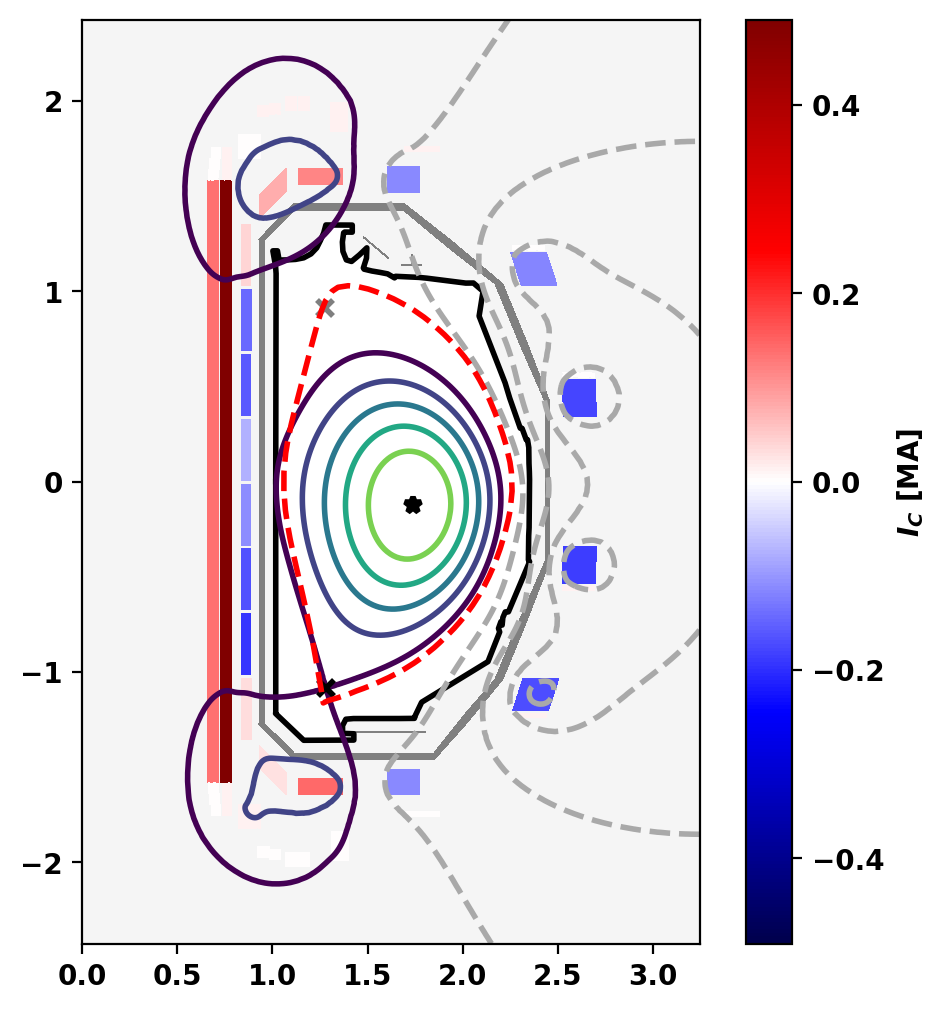

In [16]:
psi_eq = mygs.get_psi()
mygs.print_info()

fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
mygs.plot_psi(fig,ax,normalized=True,plasma_nlevels=6,vacuum_nlevels=5)
# mygs.plot_psi(fig,ax,psi_eq,plasma_levels=[1.0,],plasma_color='red',vacuum_nlevels=0,plasma_linestyles='dashed')
_ = ax.plot(eqdsk['rzout'][:,0], eqdsk['rzout'][:,1],'r--')
# plot_sensors({**fluxLoops_vv, **fluxLoops_onf}, label="Flux Loop", color='cyan')

plt.show()

In [17]:
print("Coil Currents [kA]:")
coil_currents, _ = mygs.get_coil_currents()
for key, current in coil_currents.items():
    if key not in target_currents:
        continue
    current_adj = current
    # if key.startswith('F'):
    #     current_adj = current/machine_dict['FCOIL'][key][4]
    measured_currt = target_currents[key]
    pct_diff = 100.0 * (current_adj-measured_currt)/measured_currt
    print('  {0:10} {1:11.3F} {2:11.3F} {3:10.2F}%'.format(key+":", current_adj/1.E3, measured_currt/1.E3, pct_diff))

Coil Currents [kA]:
  F1A:            -1.319      -0.409     222.45%
  F2A:            -2.733      -1.907      43.36%
  F3A:            -2.494      -2.274       9.66%
  F4A:             0.702       2.184     -67.88%
  F5A:             1.330       2.293     -41.98%
  F6A:            -3.268      -4.219     -22.53%
  F7A:            -2.160      -2.893     -25.34%
  F8A:             2.018       2.519     -19.88%
  F9A:            -2.081      -2.043       1.84%
  F1B:            -1.866      -0.593     214.88%
  F2B:            -2.903      -1.834      58.26%
  F3B:            -3.335      -2.364      41.08%
  F4B:             0.594       2.026     -70.67%
  F5B:             0.525       1.662     -68.41%
  F6B:            -3.347      -3.880     -13.75%
  F7B:            -3.075      -3.253      -5.46%
  F8B:             2.507       2.829     -11.41%
  F9B:            -2.033      -2.058      -1.24%


## Plot Measured vs. Computed SE Values

### Plot SE Currents

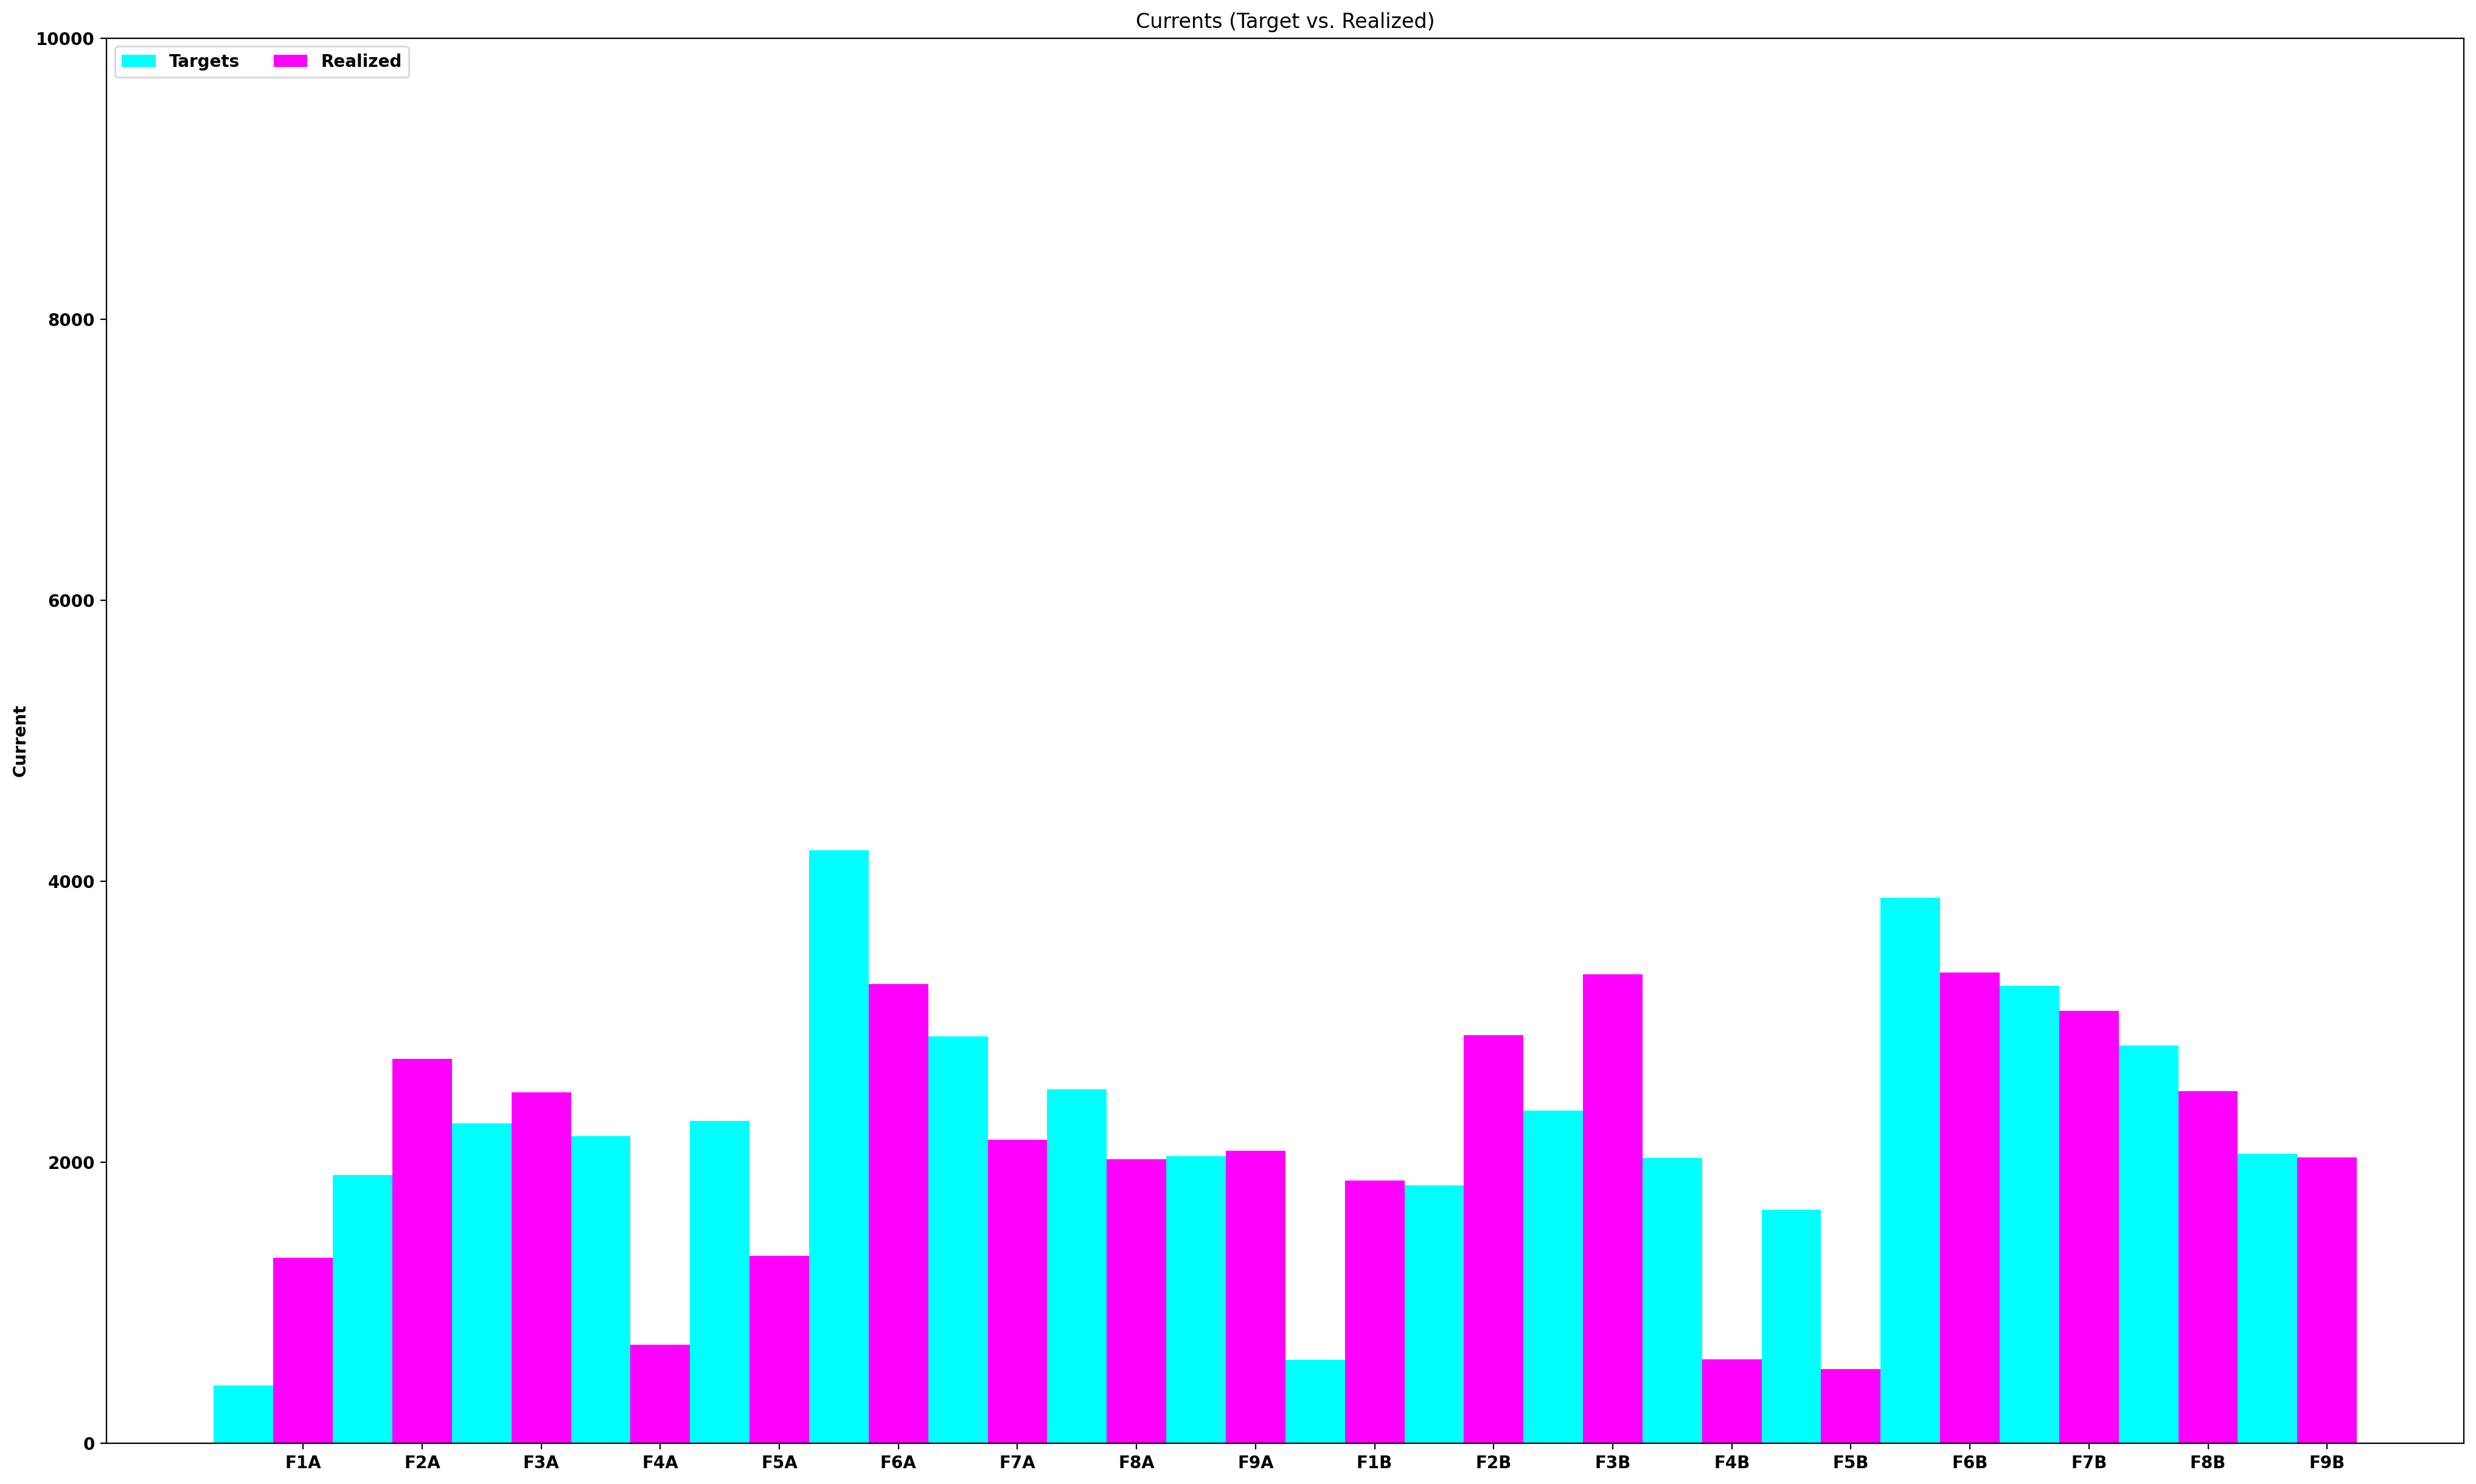

In [18]:
plot_colors = {'Targets': 'cyan', 'Realized': 'magenta', 'Error': 'blue'}

def plot_currents():
    coil_currents, _ = mygs.get_coil_currents()
    coil_names = [key for key in coil_currents if key in target_currents]
    coil_info = {'Targets': [abs(target_currents[key]) for key in coil_names if key in target_currents],
                 'Realized': [abs(coil_currents[key]) for key in coil_names if key in target_currents]}
    coil_err = np.array([np.abs(target_errs[key]) for key in coil_names if key in target_currents])

    x = np.arange(len(coil_names))  # the label locations
    width = 0.5  # the width of the bars
    multiplier = 0
    
    fig, ax = plt.subplots(figsize=(25, 15))
    
    for attribute, measurement in coil_info.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute, color=plot_colors[attribute])
        multiplier += 1
    
    ax.set_ylabel('Current')
    ax.set_title('Currents (Target vs. Realized)')
    ax.set_xticks(x + width, coil_names)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1.0E4)

    x_c = np.arange(len(coil_names))

    plt.show()

plot_currents()

### Plot SE Sensors

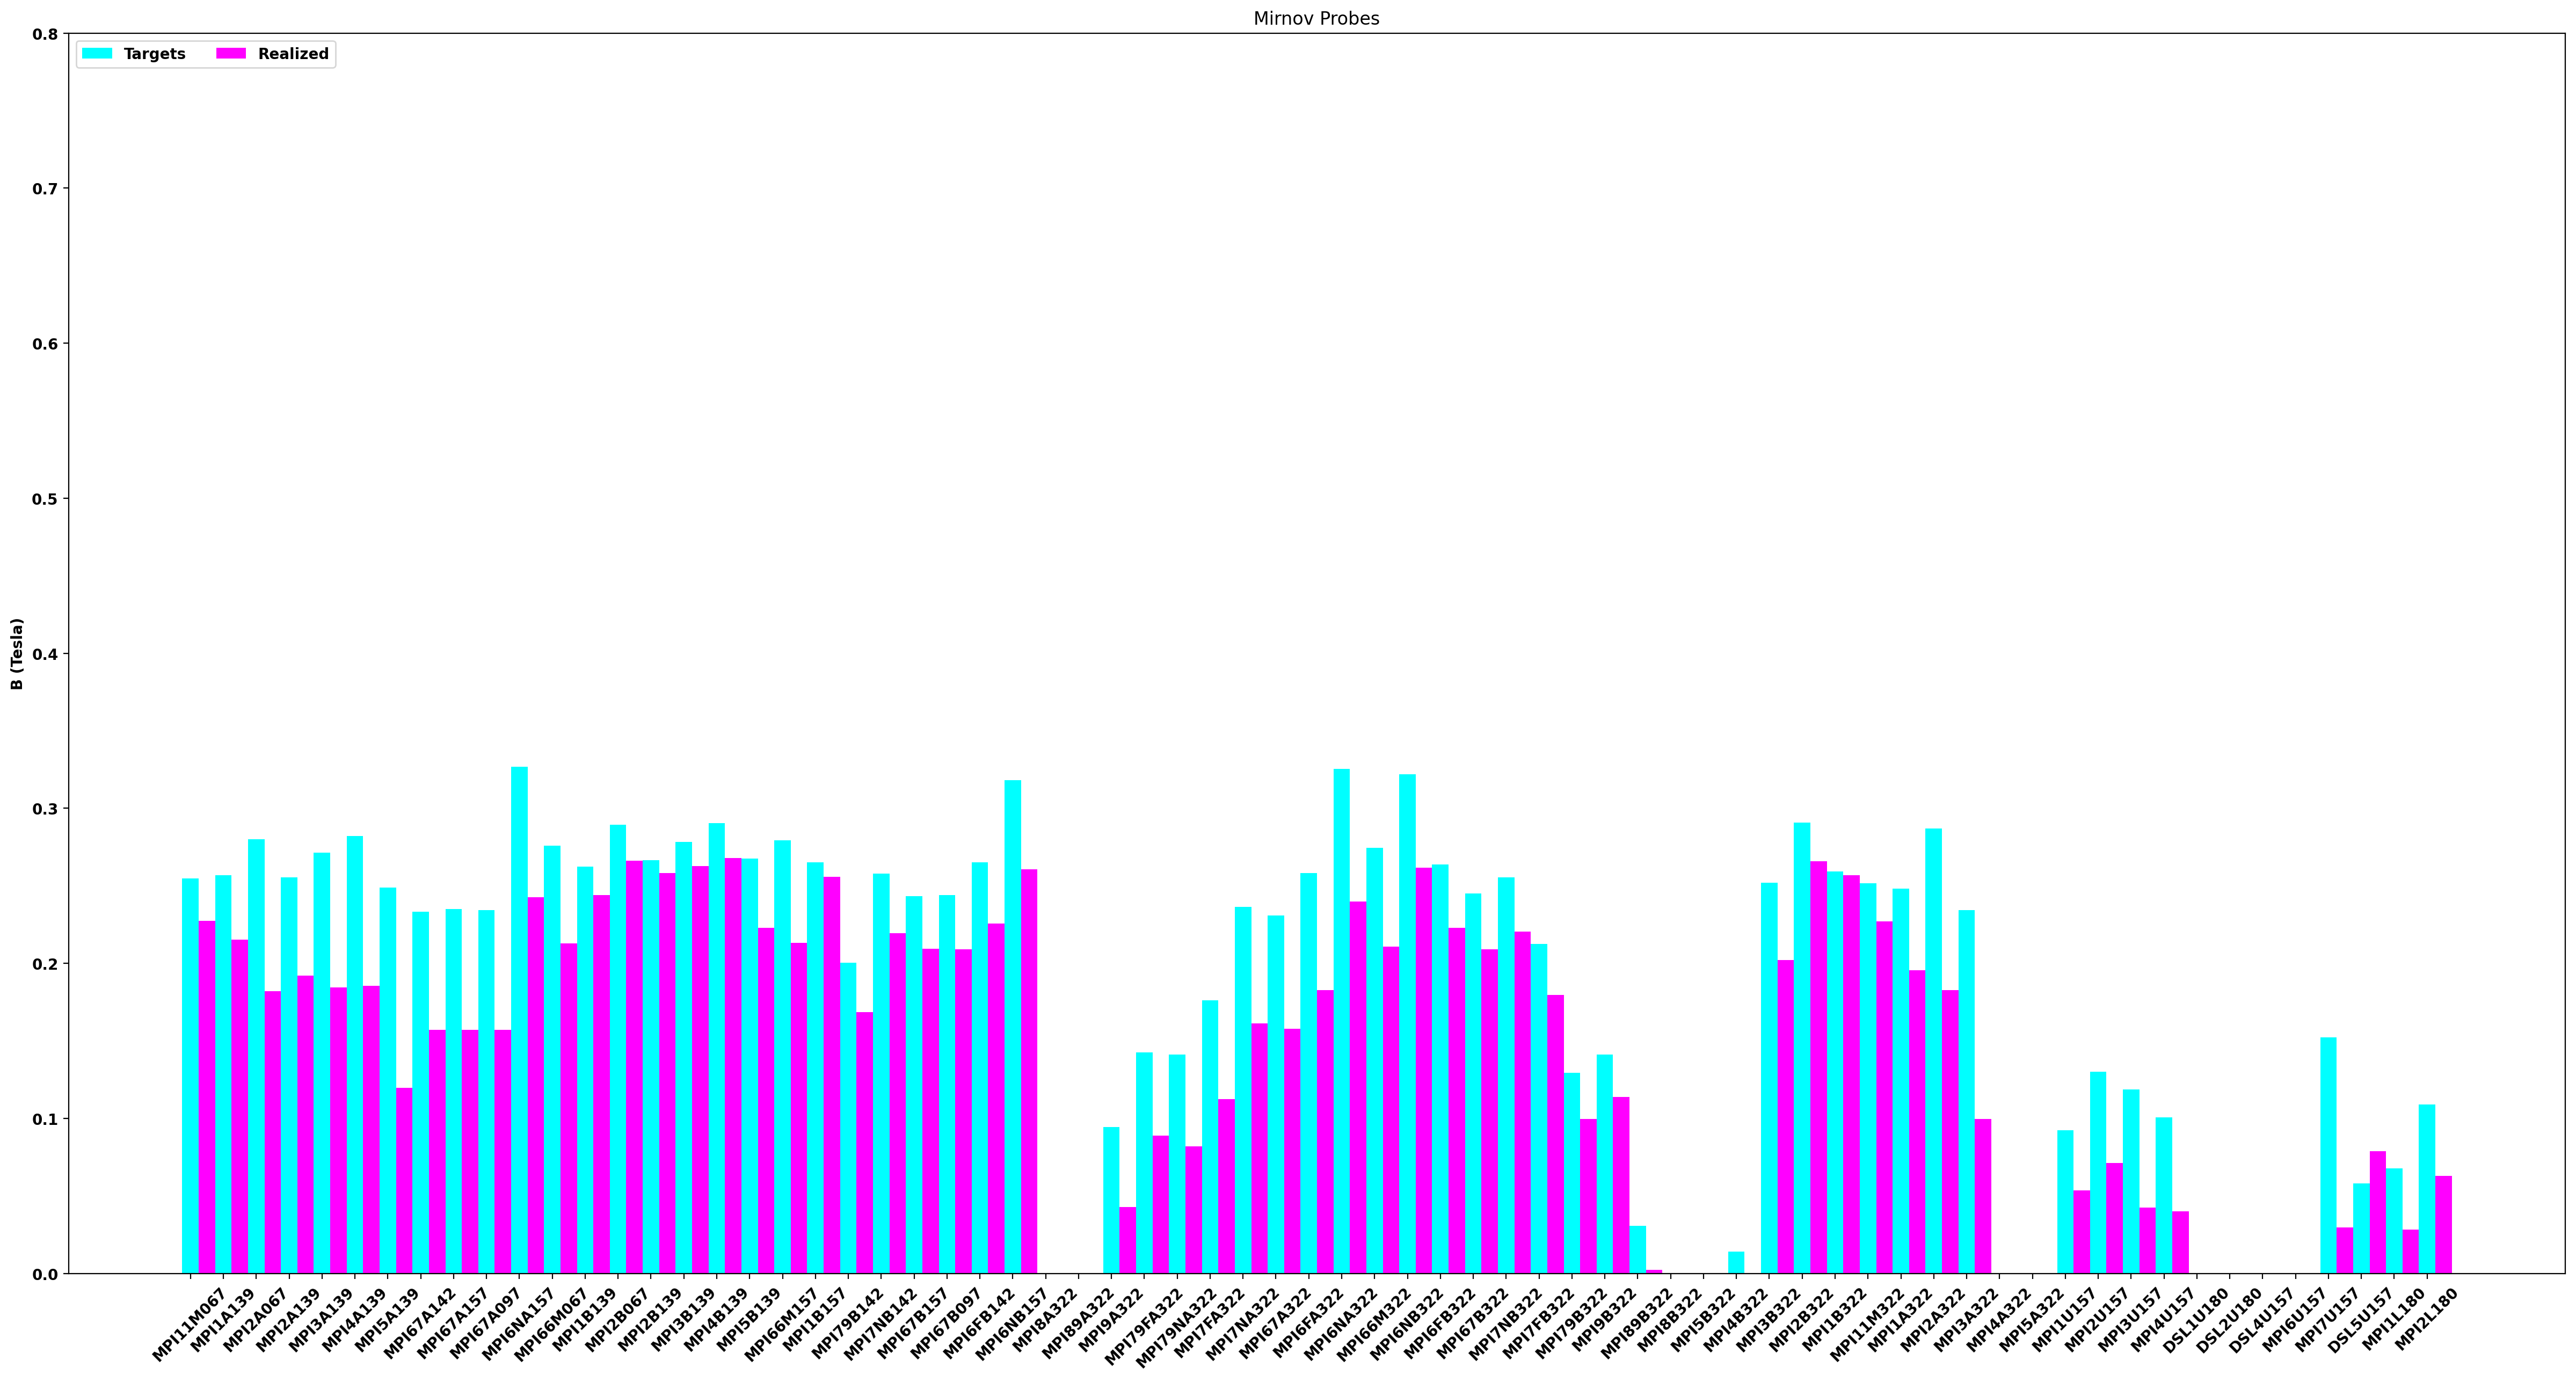

In [19]:
def plot_mirnov():
    mirnov_vals = []
    B_eval = mygs.get_field_eval('B')
    for key in mirnov_names:
        coords = mag_sensors[key]
        position, orientation = convert_Mirnov_coordinates(coords)
        B_field = B_eval.eval(position)
        mirnov_vals.append(np.dot(B_field, orientation))
    
    mirnov_targets = [probes_dict[key][0] if key in probes_dict else 0.0 for key in mirnov_names]
    mirnov_info = {'Targets': mirnov_targets,
                 'Realized': mirnov_vals}
    
    x_m = np.arange(len(mirnov_names))  # the label locations
    width = 0.5  # the width of the bars
    multiplier = 0
    
    fig, ax = plt.subplots(1, figsize=(30, 15))
    
    for attribute, measurement in mirnov_info.items():
        offset = width * multiplier
        rects_m = ax.bar(x_m + offset, measurement, width, label=attribute, color=plot_colors[attribute])
        multiplier += 1
    
    ax.set_ylabel('B (Tesla)')
    ax.set_title('Mirnov Probes')
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 0.8)
    ax.set_xticks(x_m, labels=mirnov_names, rotation=45)

    x_m = np.arange(len(mirnov_names))  # the label locations
    mirnov_mean = np.mean((np.abs(mirnov_targets)))

    plt.show()

plot_mirnov()

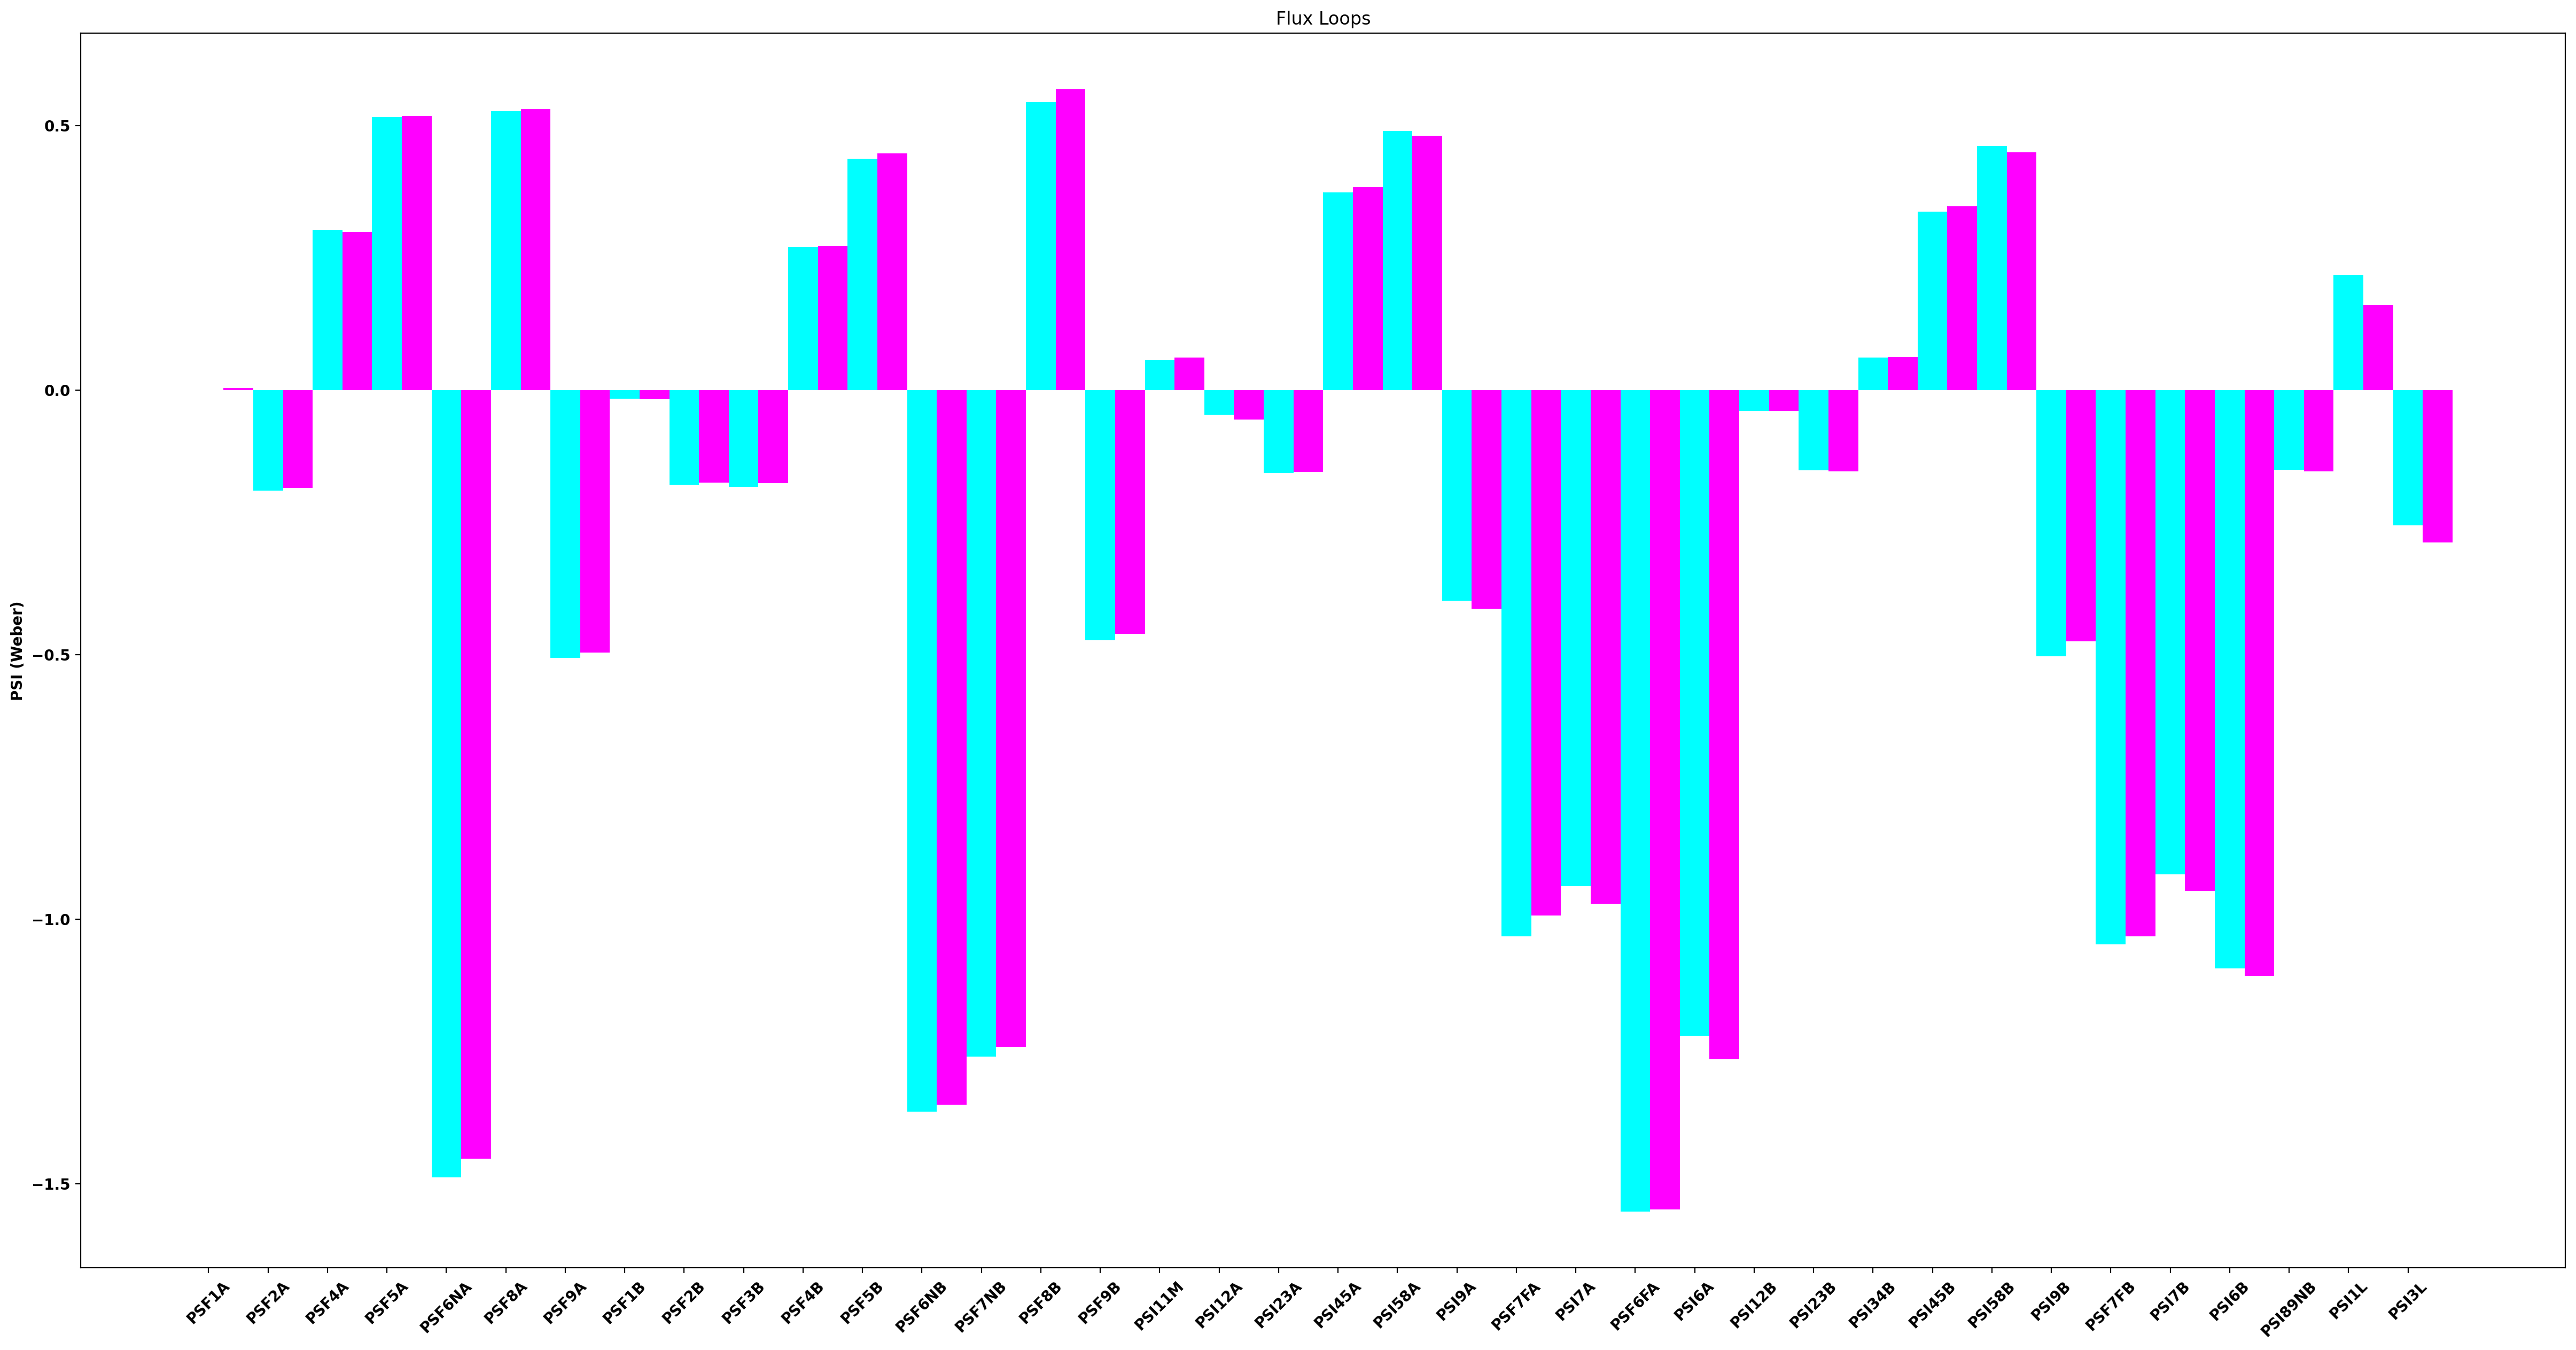

In [20]:
def plot_flux():
    flux_vals = []
    psi_eval = mygs.get_field_eval('PSI')
    for key in flux_names:
        position = flux_loops[key]
        psi_value = psi_eval.eval(position) * 2 * np.pi
        flux_vals.append(psi_value[0])

    flux_targets = [2 * np.pi * loops_dict[key][0] for key in flux_names]
    flux_errs = [2 * np.pi * loops_dict[key][1] for key in flux_names]

    figs, ax = plt.subplots(1, figsize=(30, 15))

    x_f = np.arange(len(flux_names))  # the label locations
    ax.bar(x = x_f, height = flux_targets, width=0.5, label='Targets', color=plot_colors['Targets'])
    ax.bar(x = x_f + 0.5, height = flux_vals, width=0.5, label='Realized', color=plot_colors['Realized'])

    ax.set_ylabel('PSI (Weber)')
    ax.set_title('Flux Loops')
    # ax.set_ylim(0, 1.5)
    ax.set_xticks(x_f, labels=flux_names, rotation=45)

    # ax.errorbar(x_f, flux_targets, yerr=1.0/np.abs(np.array(flux_errs)), color=plot_colors['Error'], linestyle='none', elinewidth=6.0)

    plt.show()

plot_flux()

### Perform Reconstruction

In [21]:
# Remove all shape constraints
mygs.set_isoflux(None)
mygs.set_flux(None,None)
mygs.set_saddles(None)

# Set initial position targets from current values
mygs.set_targets(R0=mygs.o_point[0],V0=mygs.o_point[1])

# Set Recon Plasma Current
myrecon.set_Ip(Ip_target, err=0.1*Ip_target)

# Set reconstruction settings
myrecon.settings.fit_Pscale = False
myrecon.settings.fitR0 = True
myrecon.settings.fitZ0 = True
myrecon.settings.fitCoils = True
myrecon.settings.pm = False

# Perform reconstructions
mygs.settings.nl_tol=1.E-6
err_flag = myrecon.reconstruct()

/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_36844/1598217038.py:2: DeprecationWarning: `set_isoflux()` is deprecated, use `set_isoflux_constraints()` instead. This function will be removed in a future version.
  mygs.set_isoflux(None)
/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_36844/1598217038.py:3: DeprecationWarning: `set_flux()` is deprecated, use `set_psi_constraints()` instead. This function will be removed in a future version.
  mygs.set_flux(None,None)
/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_36844/1598217038.py:4: DeprecationWarning: `set_saddles()` is deprecated, use `set_saddle_constraints()` instead. This function will be removed in a future version.
  mygs.set_saddles(None)
/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_36844/1598217038.py:7: DeprecationWarning: `V0` is deprecated, use `Z0` instead. This argument will be removed in a future version.
  mygs.set_targets(R0=mygs.o_point[0],V0=mygs.o_point[1])



*** Loading fit constraints ***

Starting Fit:
  # of free parameters   =   22
  # of constraints       =  108

Function evaluation    1
  FFp_scale         = -1.271E+00
  P_scale           =  1.178E+00
  R0_target         =  1.738E+00
  Z0_target         = -1.216E-01
  Coil currents [%]  = -0.000E+00 -0.000E+00 -0.000E+00  0.000E+00  0.000E+00 -0.000E+00 -0.000E+00  0.000E+00 -0.000E+00 -0.000E+00 -0.000E+00 -0.000E+00  0.000E+00  0.000E+00 -0.000E+00 -0.000E+00  0.000E+00 -0.000E+00  0.000E+00  0.000E+00
  Maximum Rel Error =  8.756E+01
  Maximum Abs Error =  8.270E+05
  Total Weighted Error   =  8.760E+02
  RMS Weighted Error     =  8.429E+01

Function evaluation    2
  FFp_scale         = -1.271E+00
  P_scale           =  1.178E+00
  R0_target         =  1.738E+00
  Z0_target         = -1.216E-01
  Coil currents [%]  = -0.000E+00 -0.000E+00 -0.000E+00  0.000E+00  0.000E+00 -0.000E+00 -0.000E+00  0.000E+00 -0.000E+00 -0.000E+00 -0.000E+00 -0.000E+00  0.000E+00  0.000E+00 -0.000E+00

### Print equilibrium information and coil currents
As above we use \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.print_info "print_info()" and \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.get_coil_currents "get_coil_currents()" to display information on the final equilibrium.

In [22]:
mygs.print_info()

print()
print("Coil Currents [kA]:")
coil_currents, _ = mygs.get_coil_currents()
for key, current in coil_currents.items():
    if key not in target_currents:
        continue
    measured_currt = target_currents[key]
    pct_diff = 100.0 * (current-measured_currt)/measured_currt
    print('  {0:10} {1:11.3F} {2:11.3F} {3:10.2F}%'.format(key+":", current/1.E3, measured_currt/1.E3, pct_diff))

Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    8.1015E+05
  Current Centroid [m]    =    1.688 -0.130
  Magnetic Axis [m]       =    1.738 -0.122
  Elongation              =    1.492 (U:  1.353, L:  1.632)
  Triangularity           =    0.334 (U:  0.112, L:  0.557)
  Plasma Volume [m^3]     =   15.070
  q_0, q_95               =   -13.626 -50.525
  Plasma Pressure [Pa]    =   Axis:  1.0486E+05, Peak:  1.0486E+05
  Stored Energy [J]       =    7.8100E+05
  <Beta_pol> [%]          =   177.5619
  <Beta_tor> [%]          =    0.0208
  <Beta_n>   [%]          =    0.3099
  Diamagnetic flux [Wb]   =    4.4437E-04
  Toroidal flux [Wb]      =   -3.2321E+01
  l_i                     =    1.0684

Coil Currents [kA]:
  F1A:            -1.319      -0.409     222.45%
  F2A:            -2.733      -1.907      43.36%
  F3A:            -2.494      -2.274       9.66%
  F4A:             0.702       2.184     -67.88%
  F5A:             1.330       2.293     

## Plot final reconstructed equilibrium

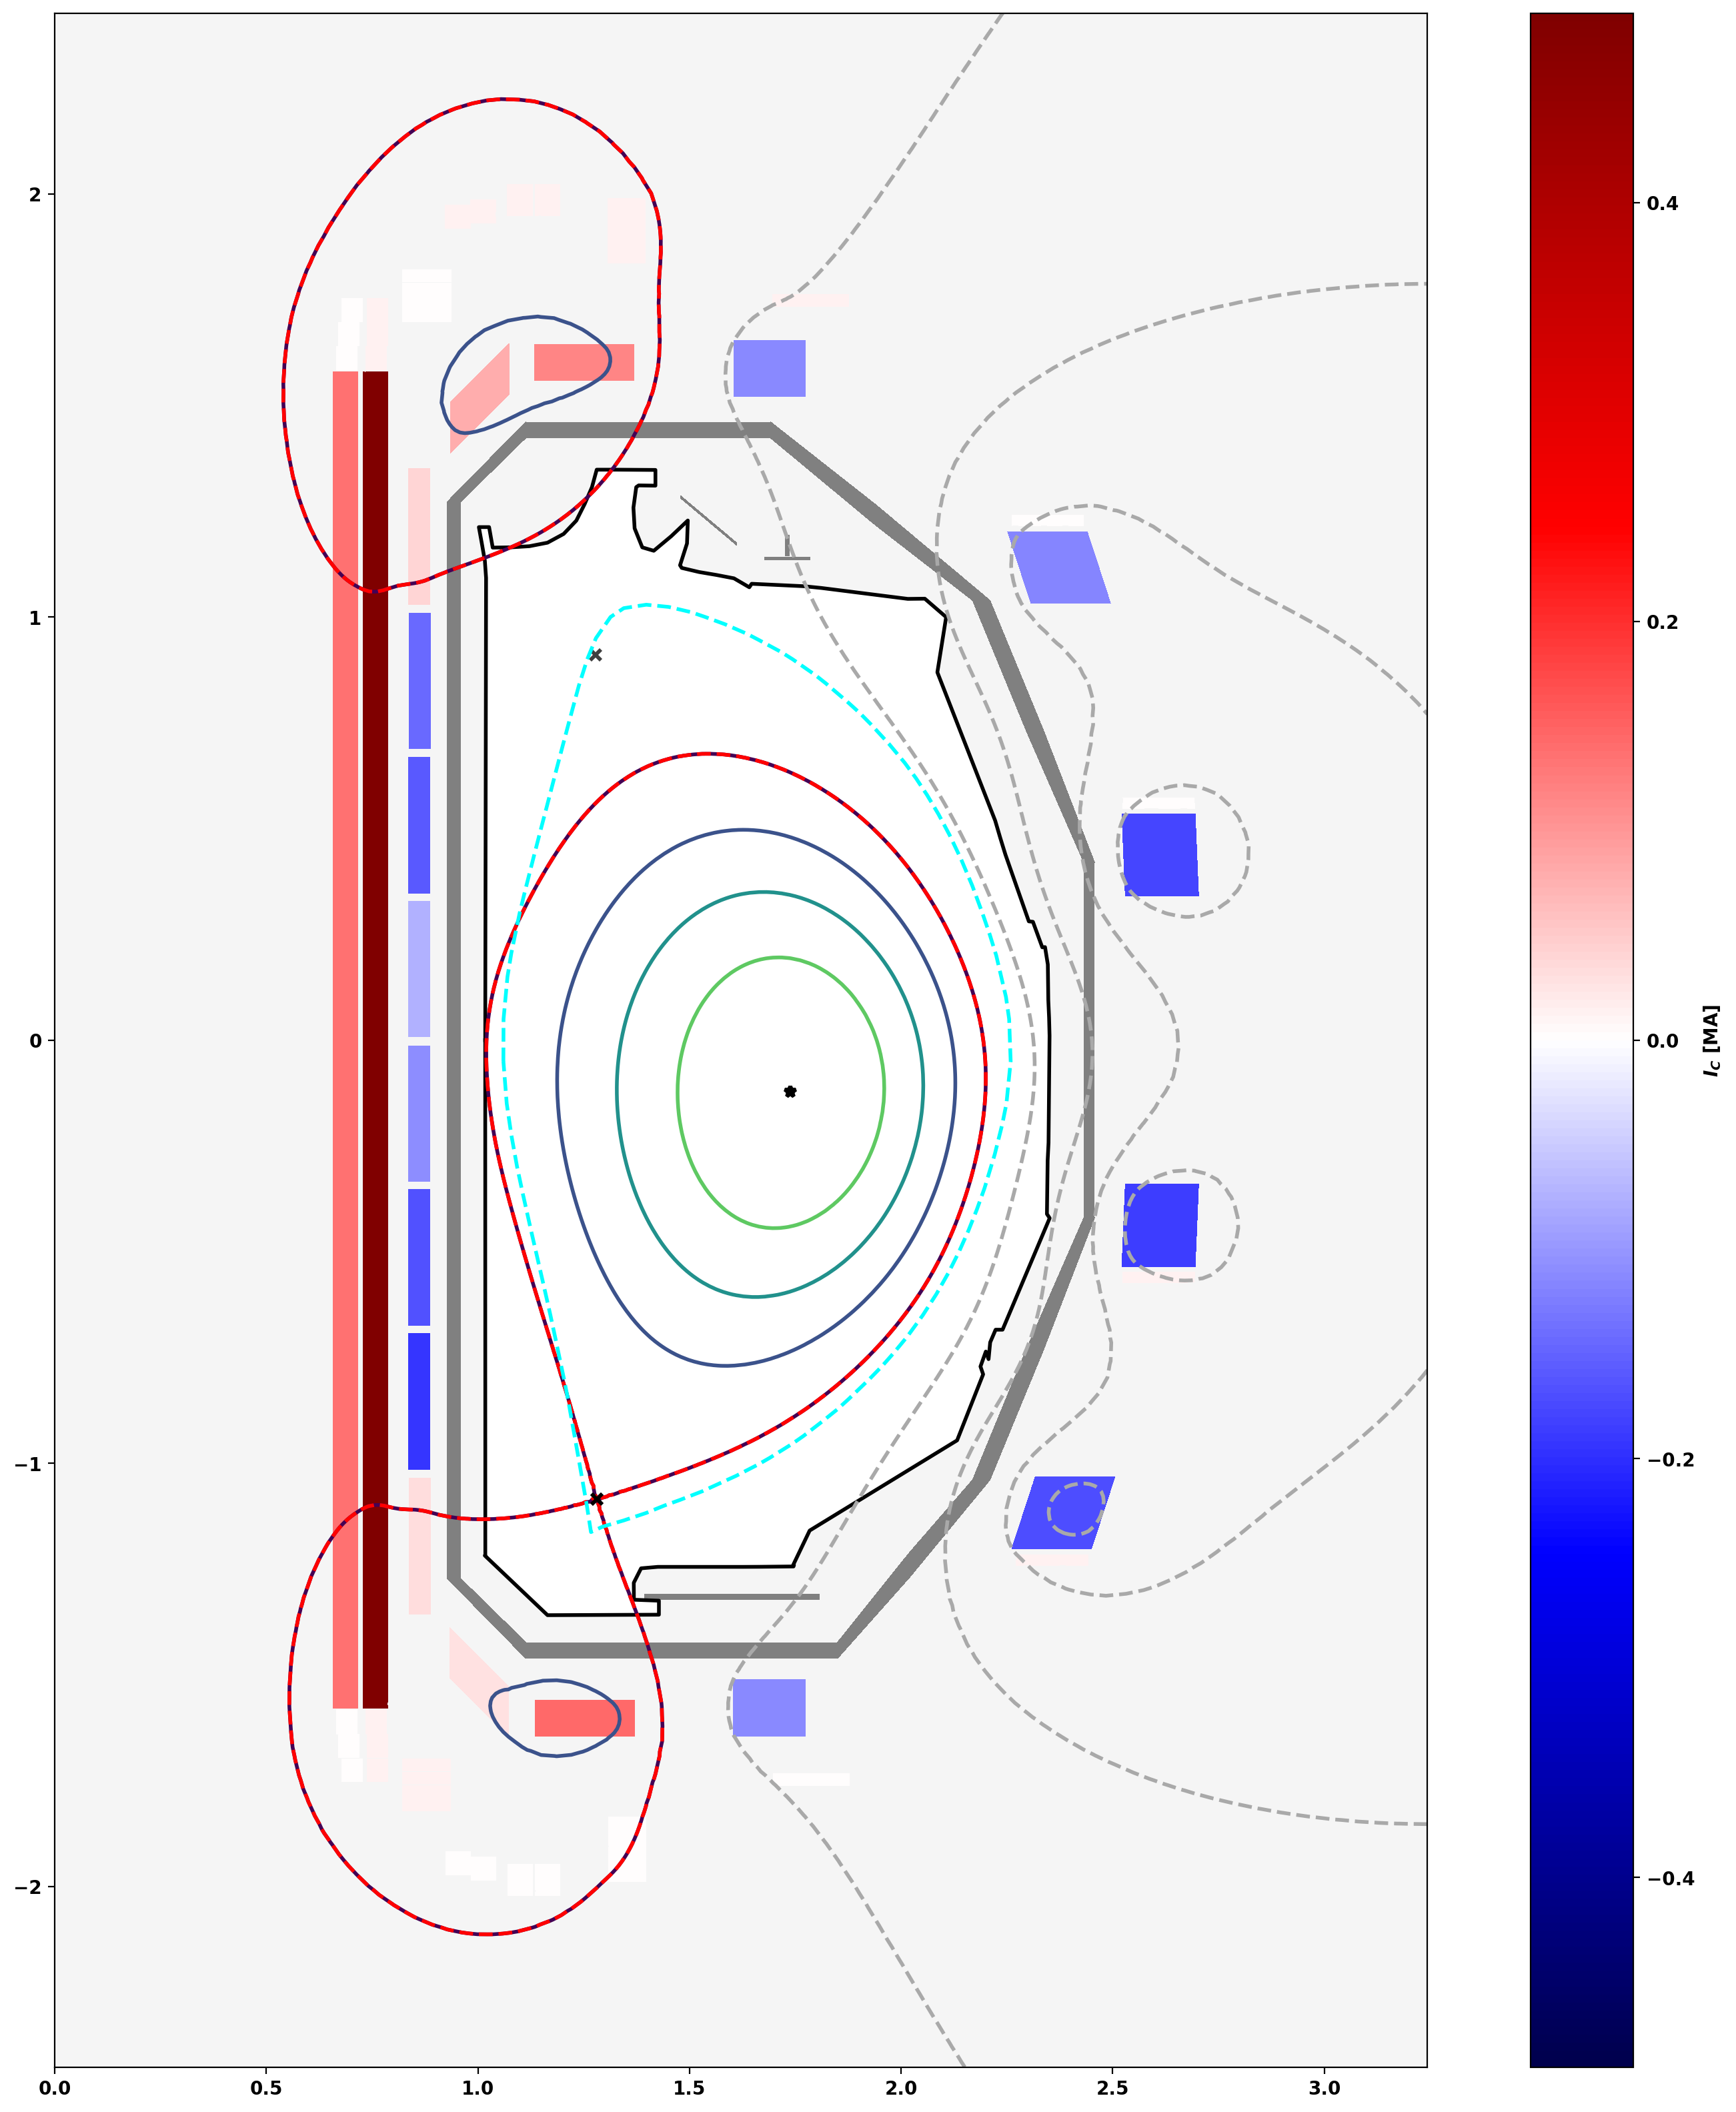

In [23]:
from matplotlib.colors import ListedColormap
fig, ax = plt.subplots(1,1, figsize=(20,20))

# Plot Psi
psi_recons = mygs.get_psi()
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5)
mygs.plot_psi(fig,ax,psi=psi_recons,plasma_levels=[1.0,],plasma_color='red',vacuum_nlevels=0,plasma_linestyles='dashed')

LCFS_eqdsk = eqdsk['rzout']
ax.plot(LCFS_eqdsk[:,0], LCFS_eqdsk[:,1], color='cyan', linestyle='--')

plt.show()

## Plot Current Density

Starting CG solver
     0  0.000000E+00  0.000000E+00  4.819364E-01
     1 -3.677343E+02  1.955352E+03  1.686968E-01  8.627438E-05
     2 -4.081914E+02  2.141275E+03  7.200053E-02  3.362508E-05
     3 -4.124224E+02  2.213011E+03  2.856873E-02  1.290944E-05
     4 -4.130639E+02  2.224593E+03  1.057943E-02  4.755671E-06
     5 -4.131530E+02  2.225117E+03  3.856192E-03  1.733029E-06
     6 -4.131665E+02  2.221425E+03  1.416817E-03  6.377966E-07
     7 -4.131682E+02  2.220071E+03  5.114183E-04  2.303613E-07
     8 -4.131684E+02  2.219838E+03  2.081101E-04  9.375013E-08
     9 -4.131684E+02  2.219809E+03  8.196470E-05  3.692421E-08
    10 -4.131684E+02  2.219823E+03  3.478853E-05  1.567176E-08
    20 -4.131684E+02  2.219852E+03  2.486862E-09  1.120283E-12


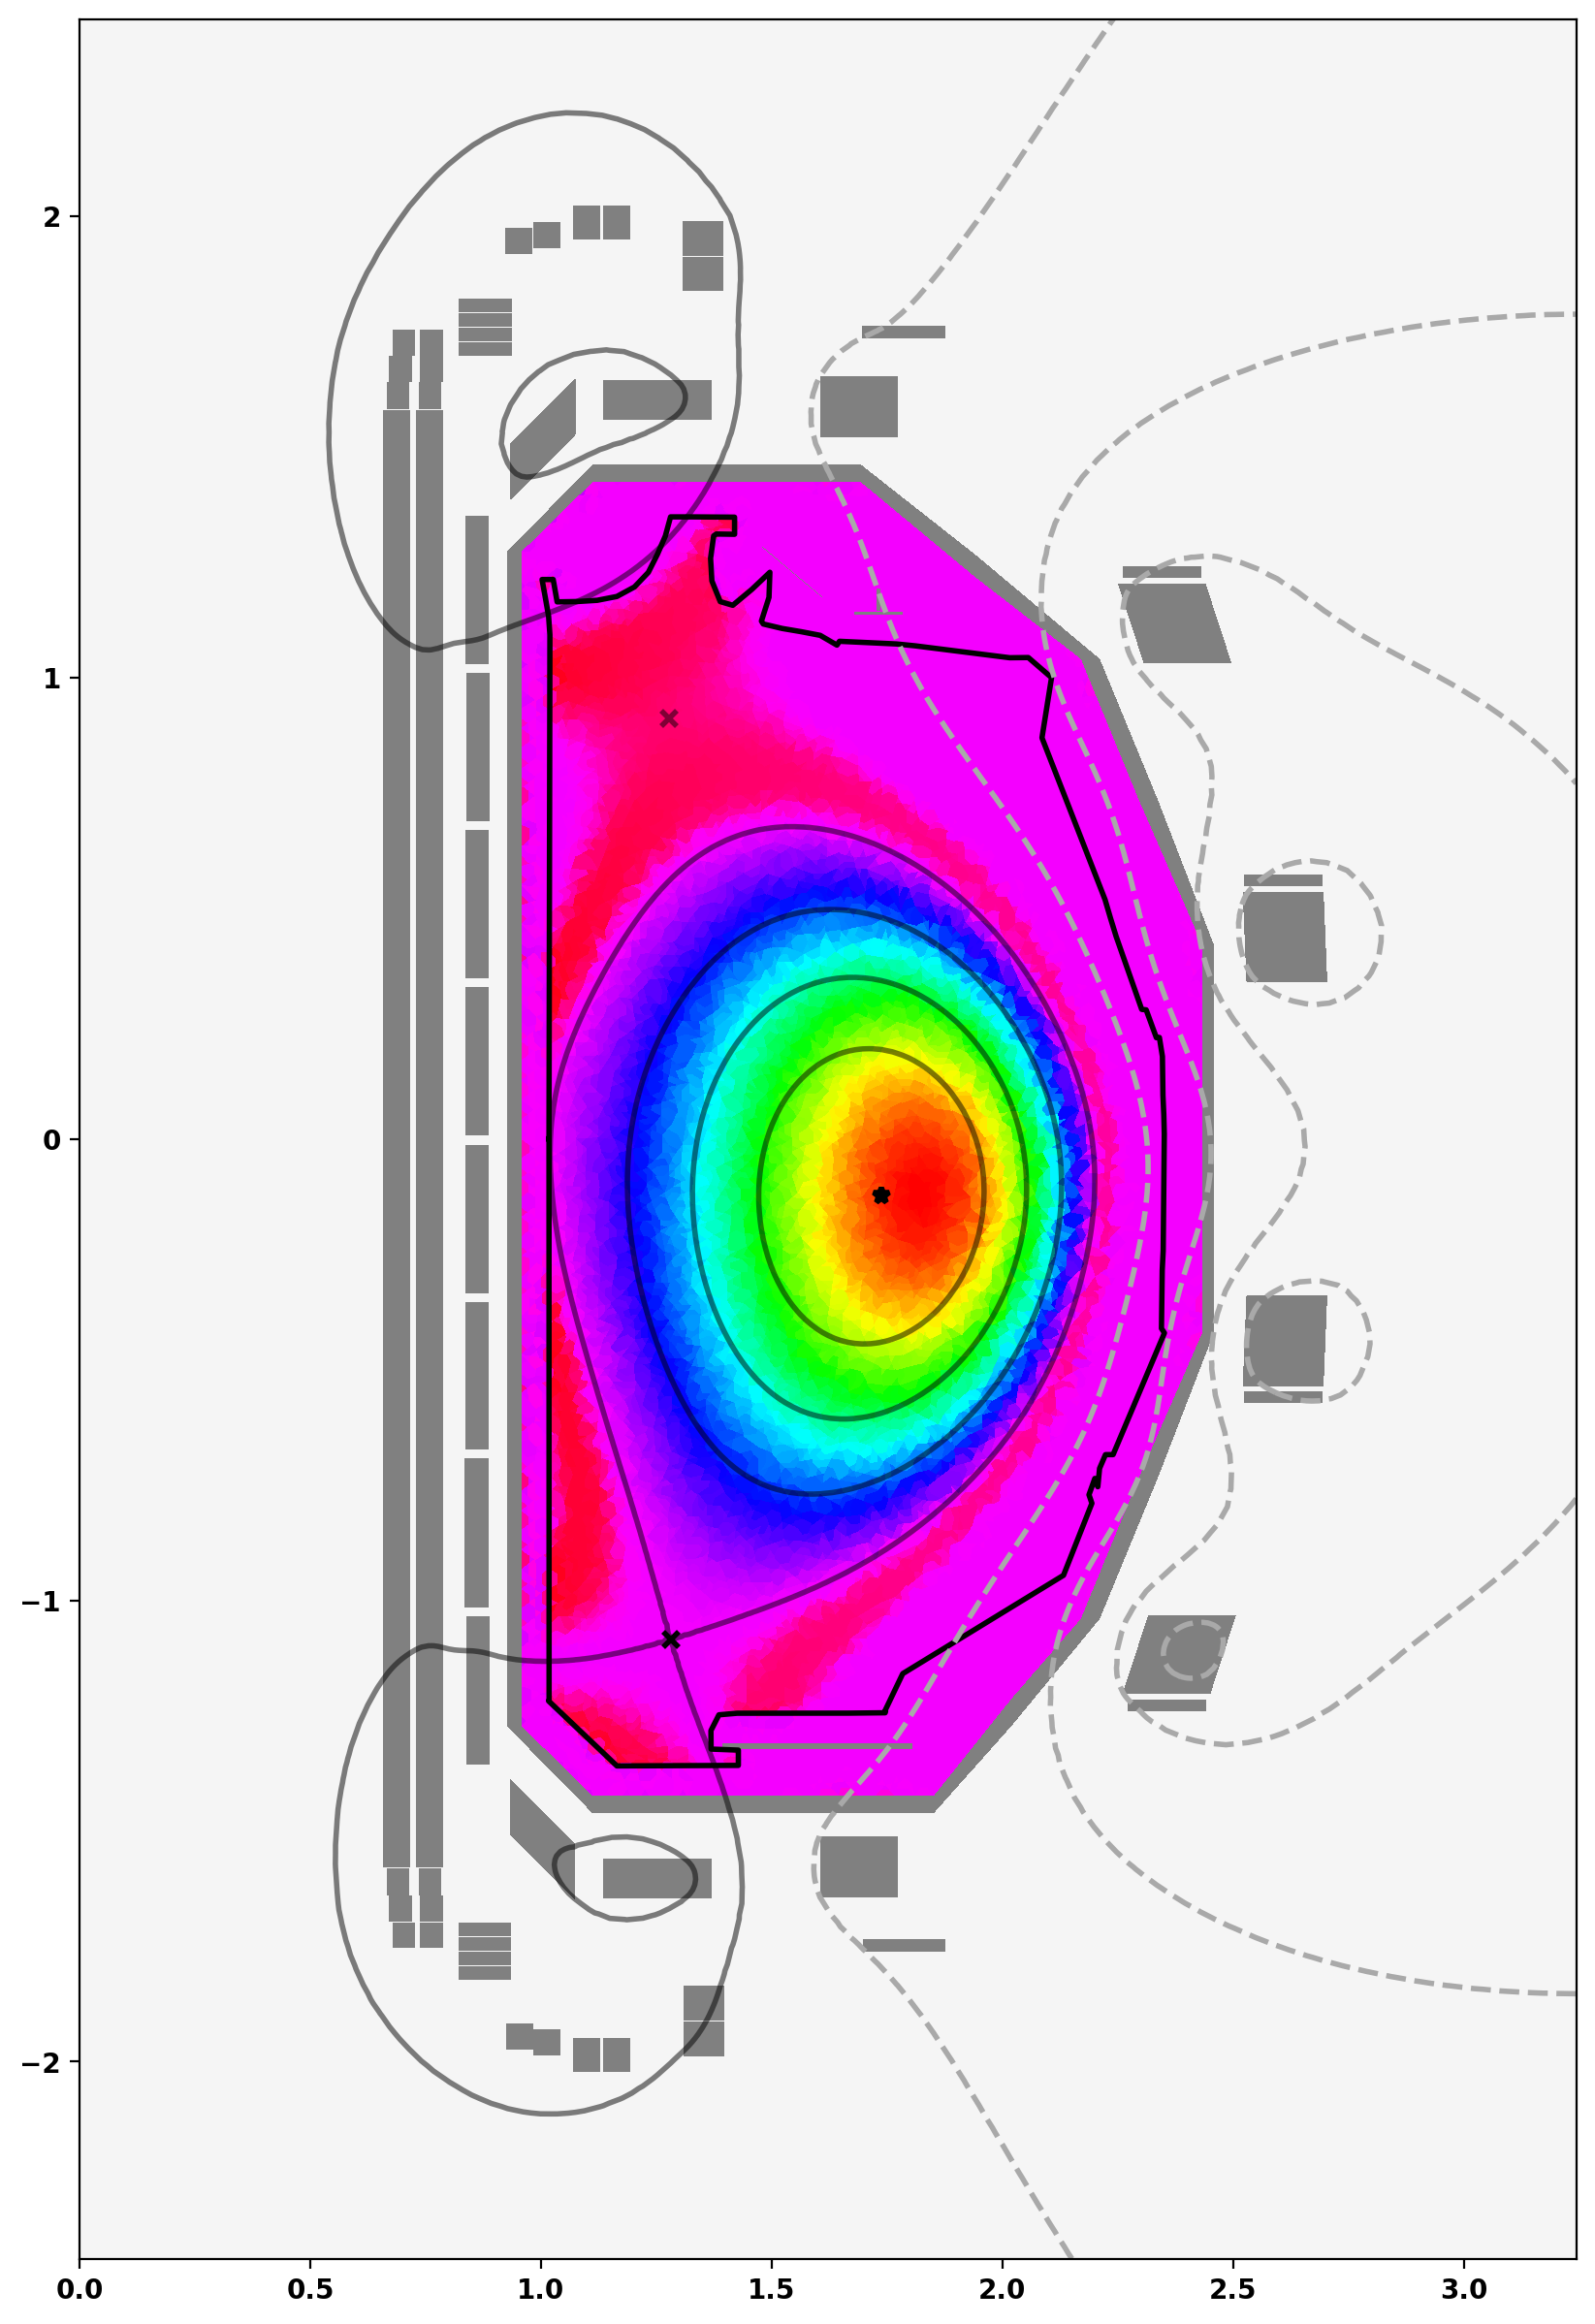

In [24]:
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(1,1, figsize=(15,15))
cmap = ListedColormap([[0.0, 0.0, 0.0, 0.5]])

mygs.plot_machine(fig,ax,coil_clabel=None)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5, plasma_colormap=cmap)
mygs.plot_current_density(fig, ax, cmap='hsv')

# Show the plot
plt.show()

## Plot Current Density in Divertor Region

Starting CG solver
     0  0.000000E+00  0.000000E+00  4.819364E-01
     1 -3.677343E+02  1.955352E+03  1.686968E-01  8.627438E-05
     2 -4.081914E+02  2.141275E+03  7.200053E-02  3.362508E-05
     3 -4.124224E+02  2.213011E+03  2.856873E-02  1.290944E-05
     4 -4.130639E+02  2.224593E+03  1.057943E-02  4.755671E-06
     5 -4.131530E+02  2.225117E+03  3.856192E-03  1.733029E-06
     6 -4.131665E+02  2.221425E+03  1.416817E-03  6.377966E-07
     7 -4.131682E+02  2.220071E+03  5.114183E-04  2.303613E-07
     8 -4.131684E+02  2.219838E+03  2.081101E-04  9.375013E-08
     9 -4.131684E+02  2.219809E+03  8.196470E-05  3.692421E-08
    10 -4.131684E+02  2.219823E+03  3.478853E-05  1.567176E-08
    20 -4.131684E+02  2.219852E+03  2.486862E-09  1.120283E-12


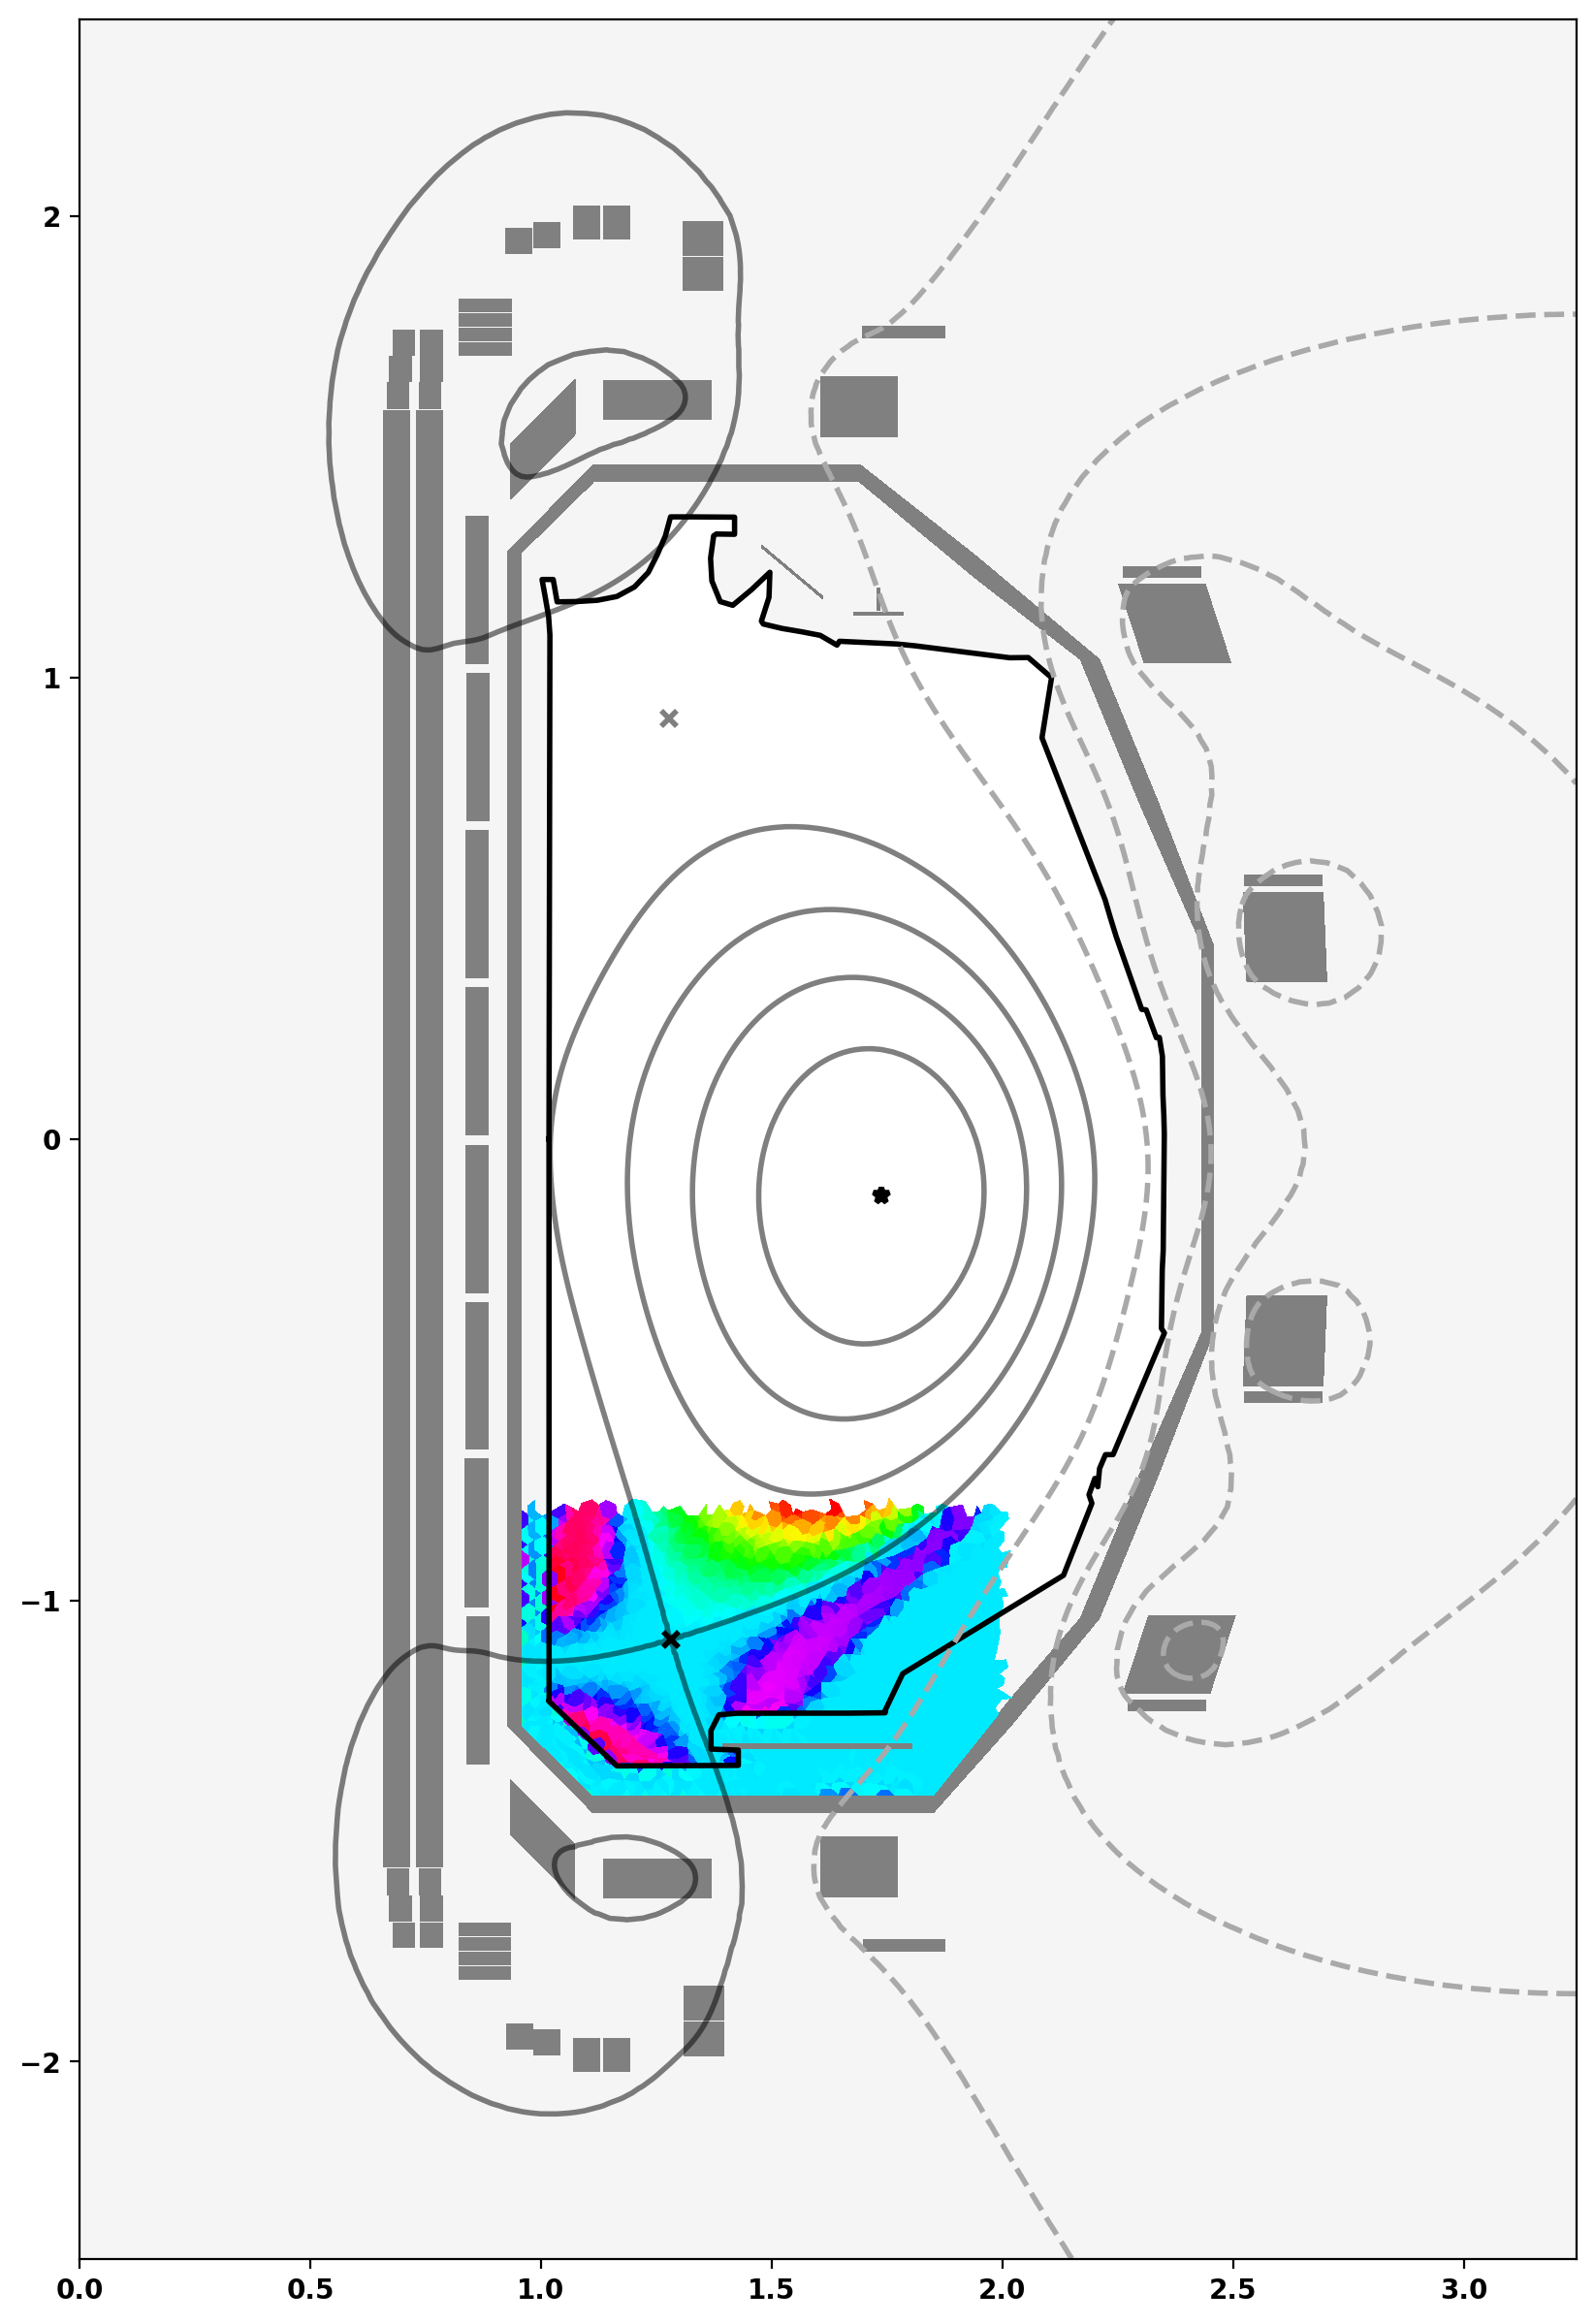

In [31]:
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(1,1, figsize=(15,15))
cmap = ListedColormap([[0.0, 0.0, 0.0, 0.5]])

mygs.plot_machine(fig,ax,coil_clabel=None)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5, plasma_colormap=cmap)
mygs.plot_current_density(fig, ax, window=[0.8, 2.0, -2.0, -0.8], cmap='hsv')

# Show the plot
plt.show()

## Plot Currents

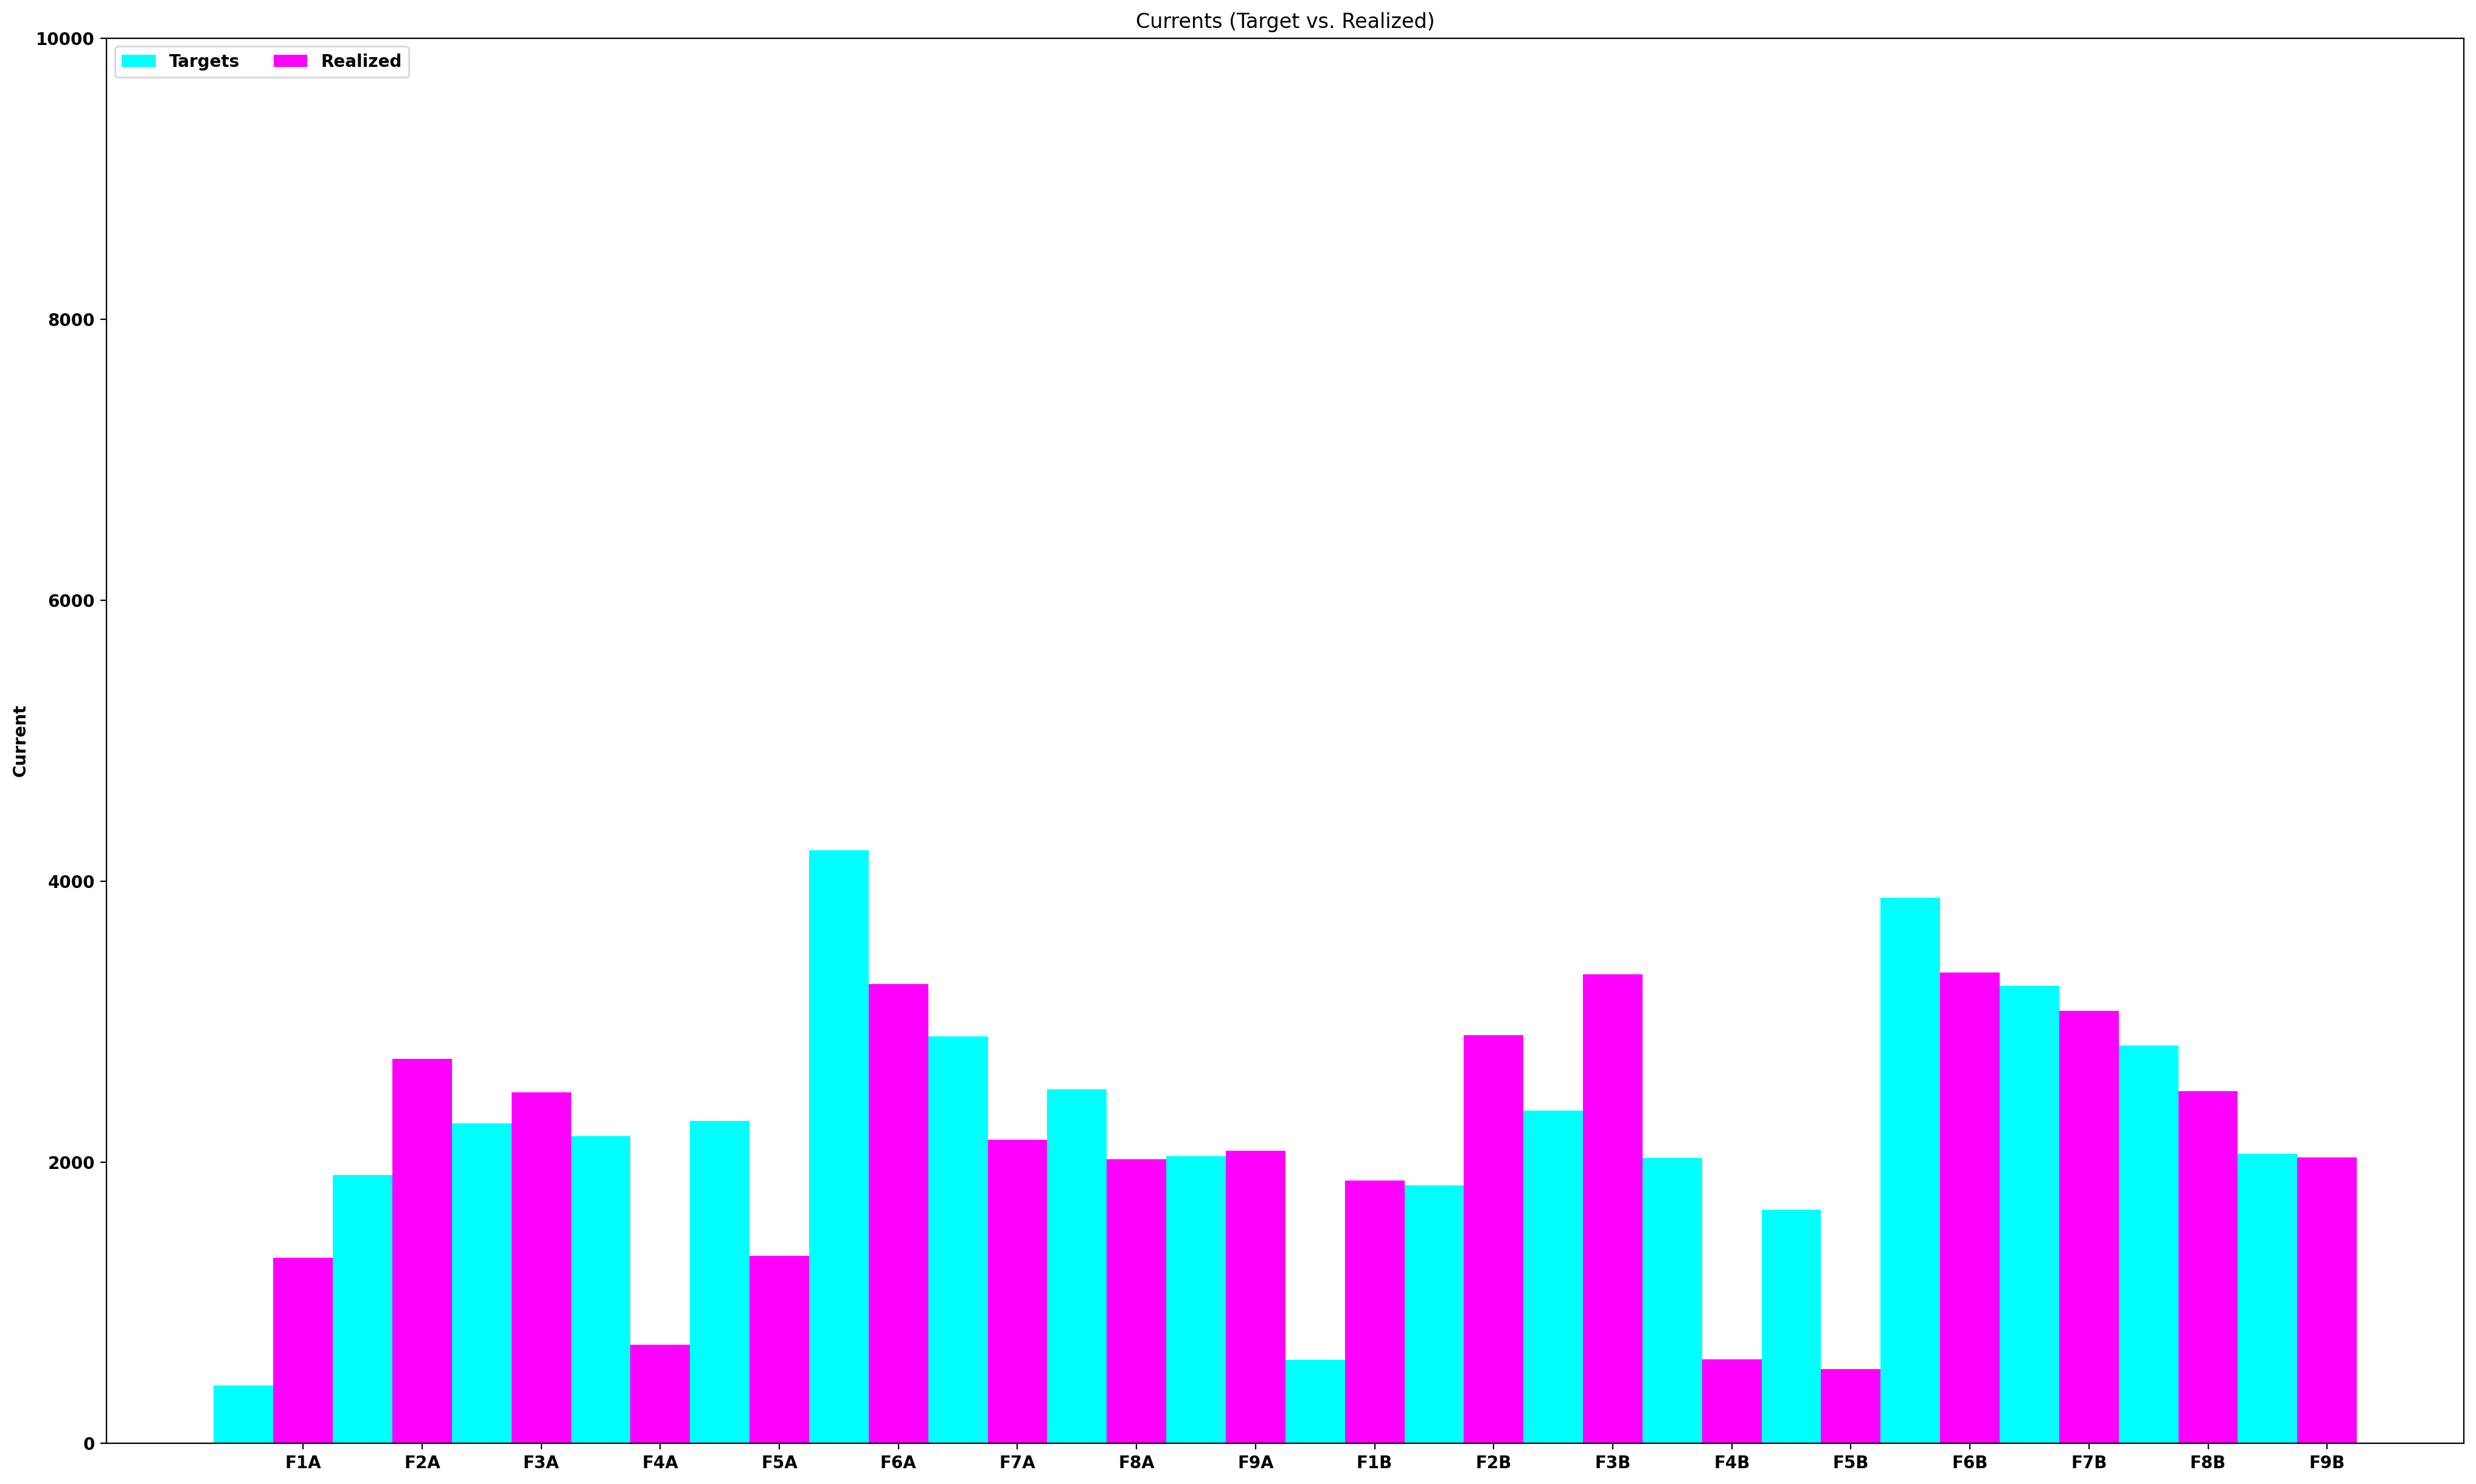

In [26]:
plot_currents()

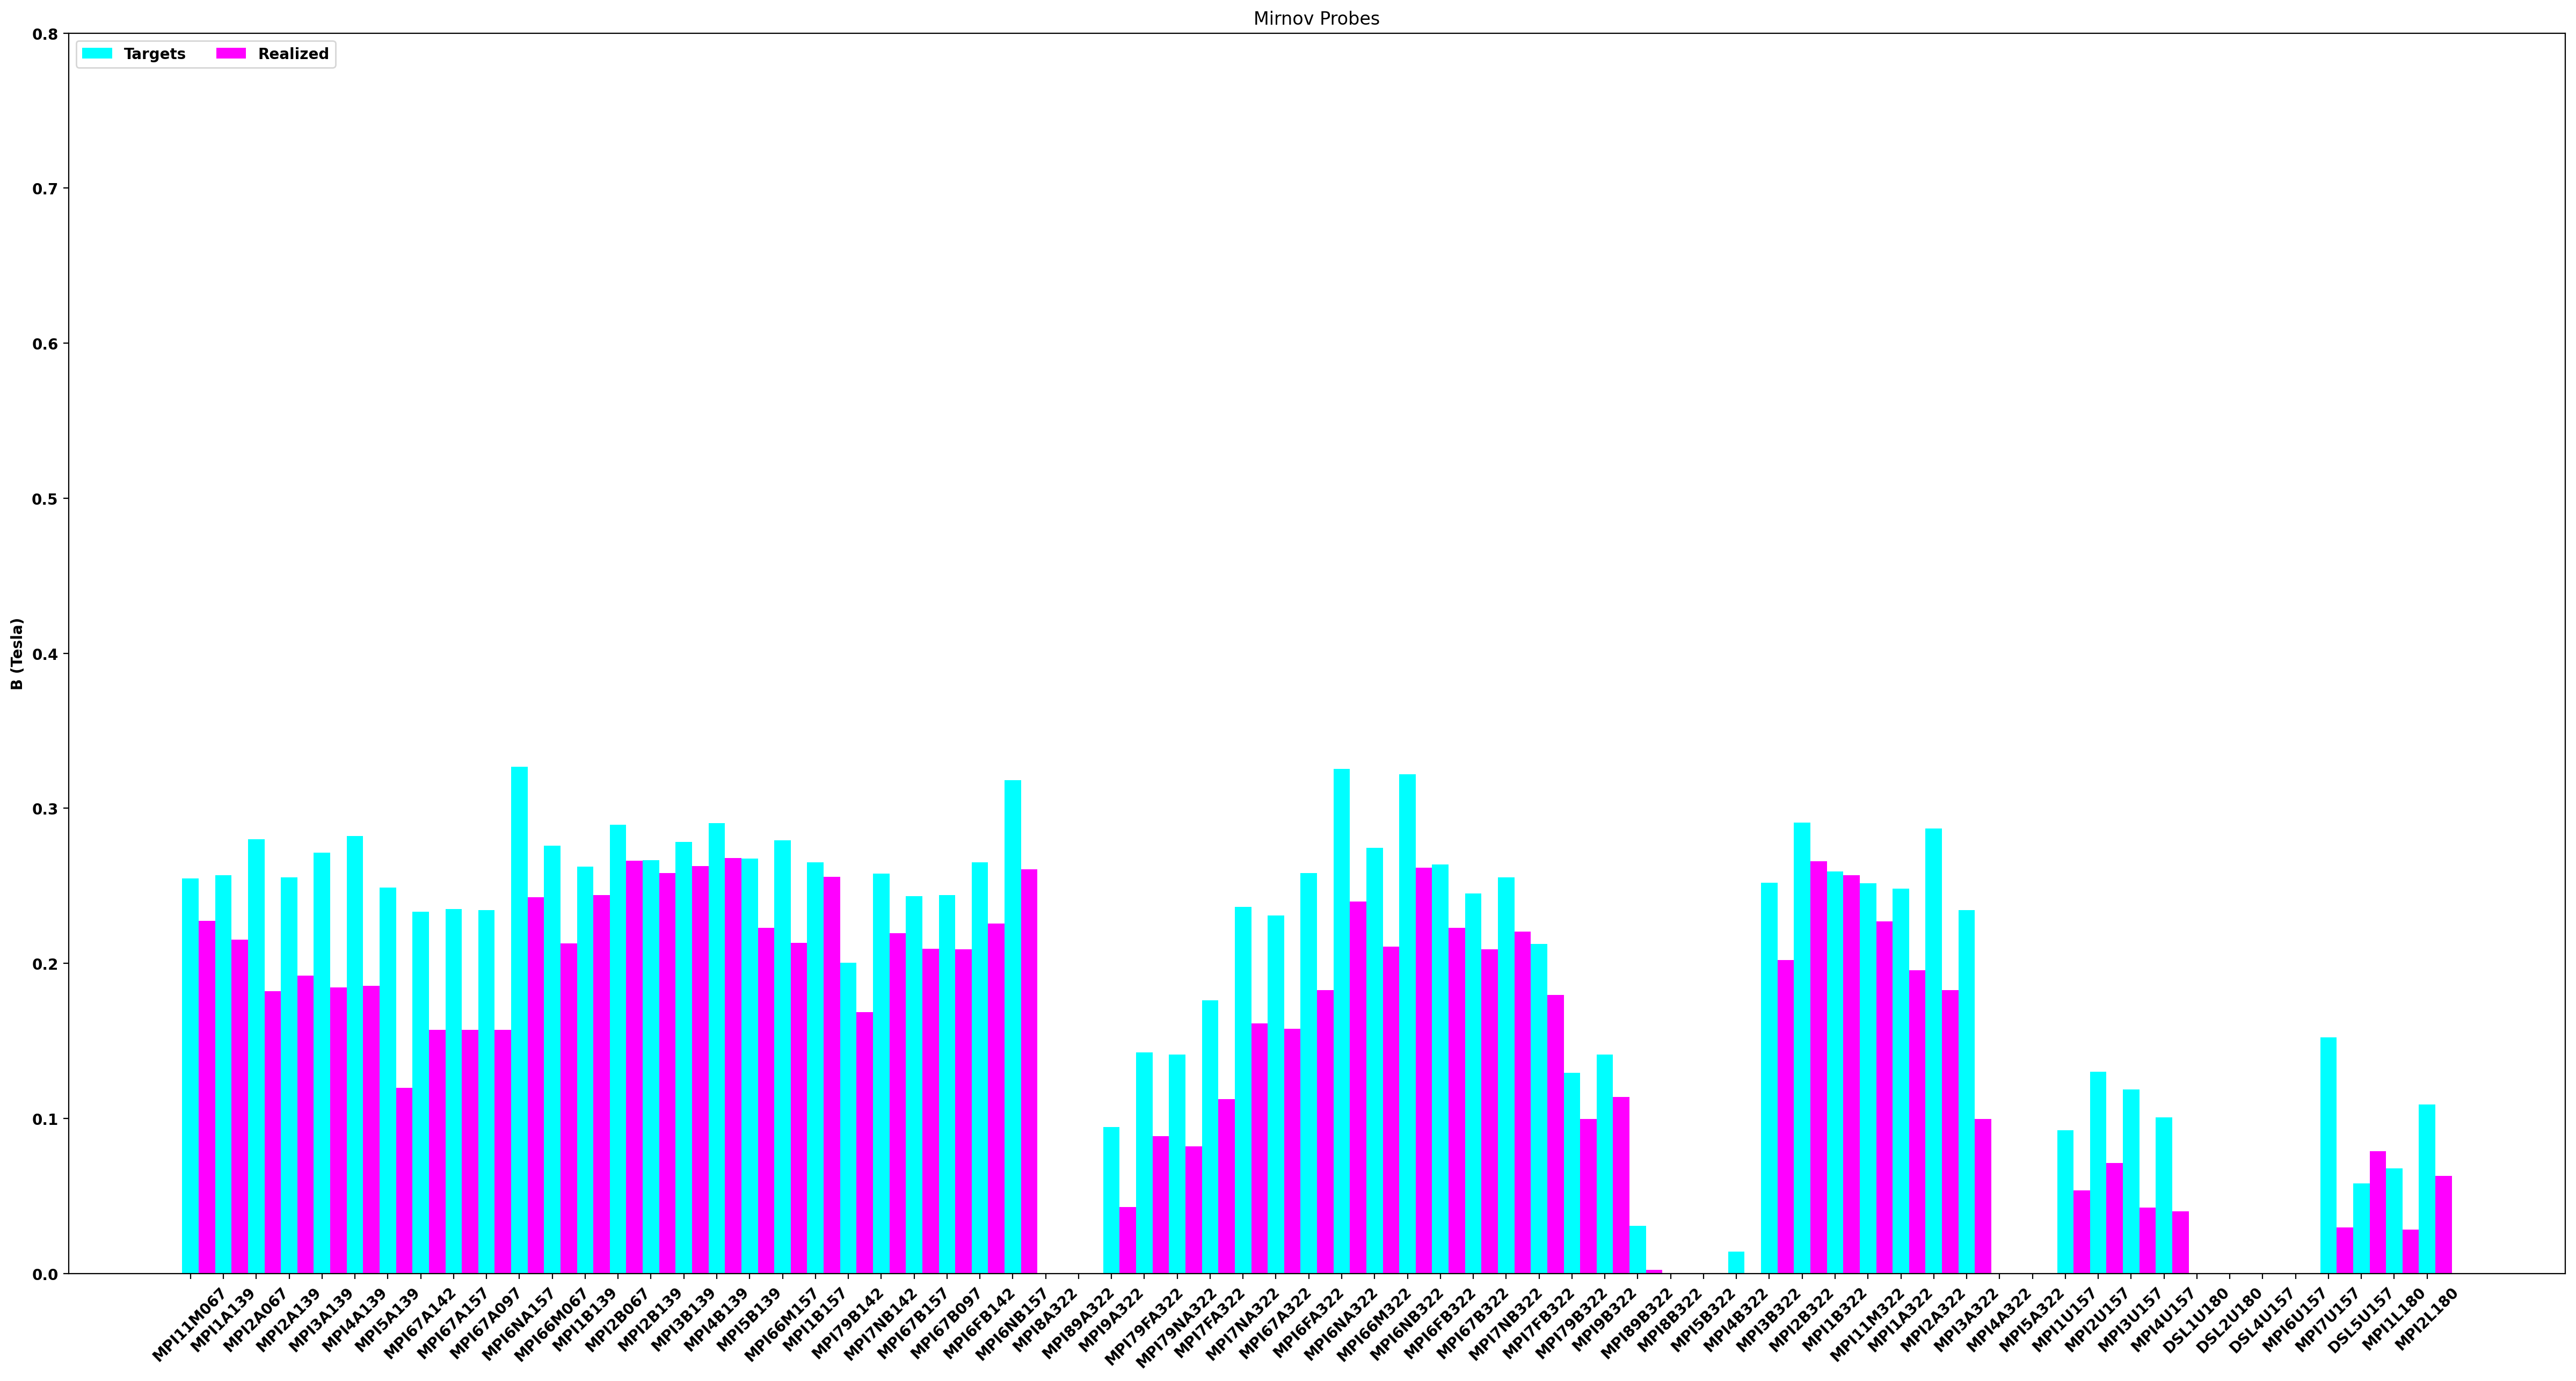

In [27]:
plot_mirnov()

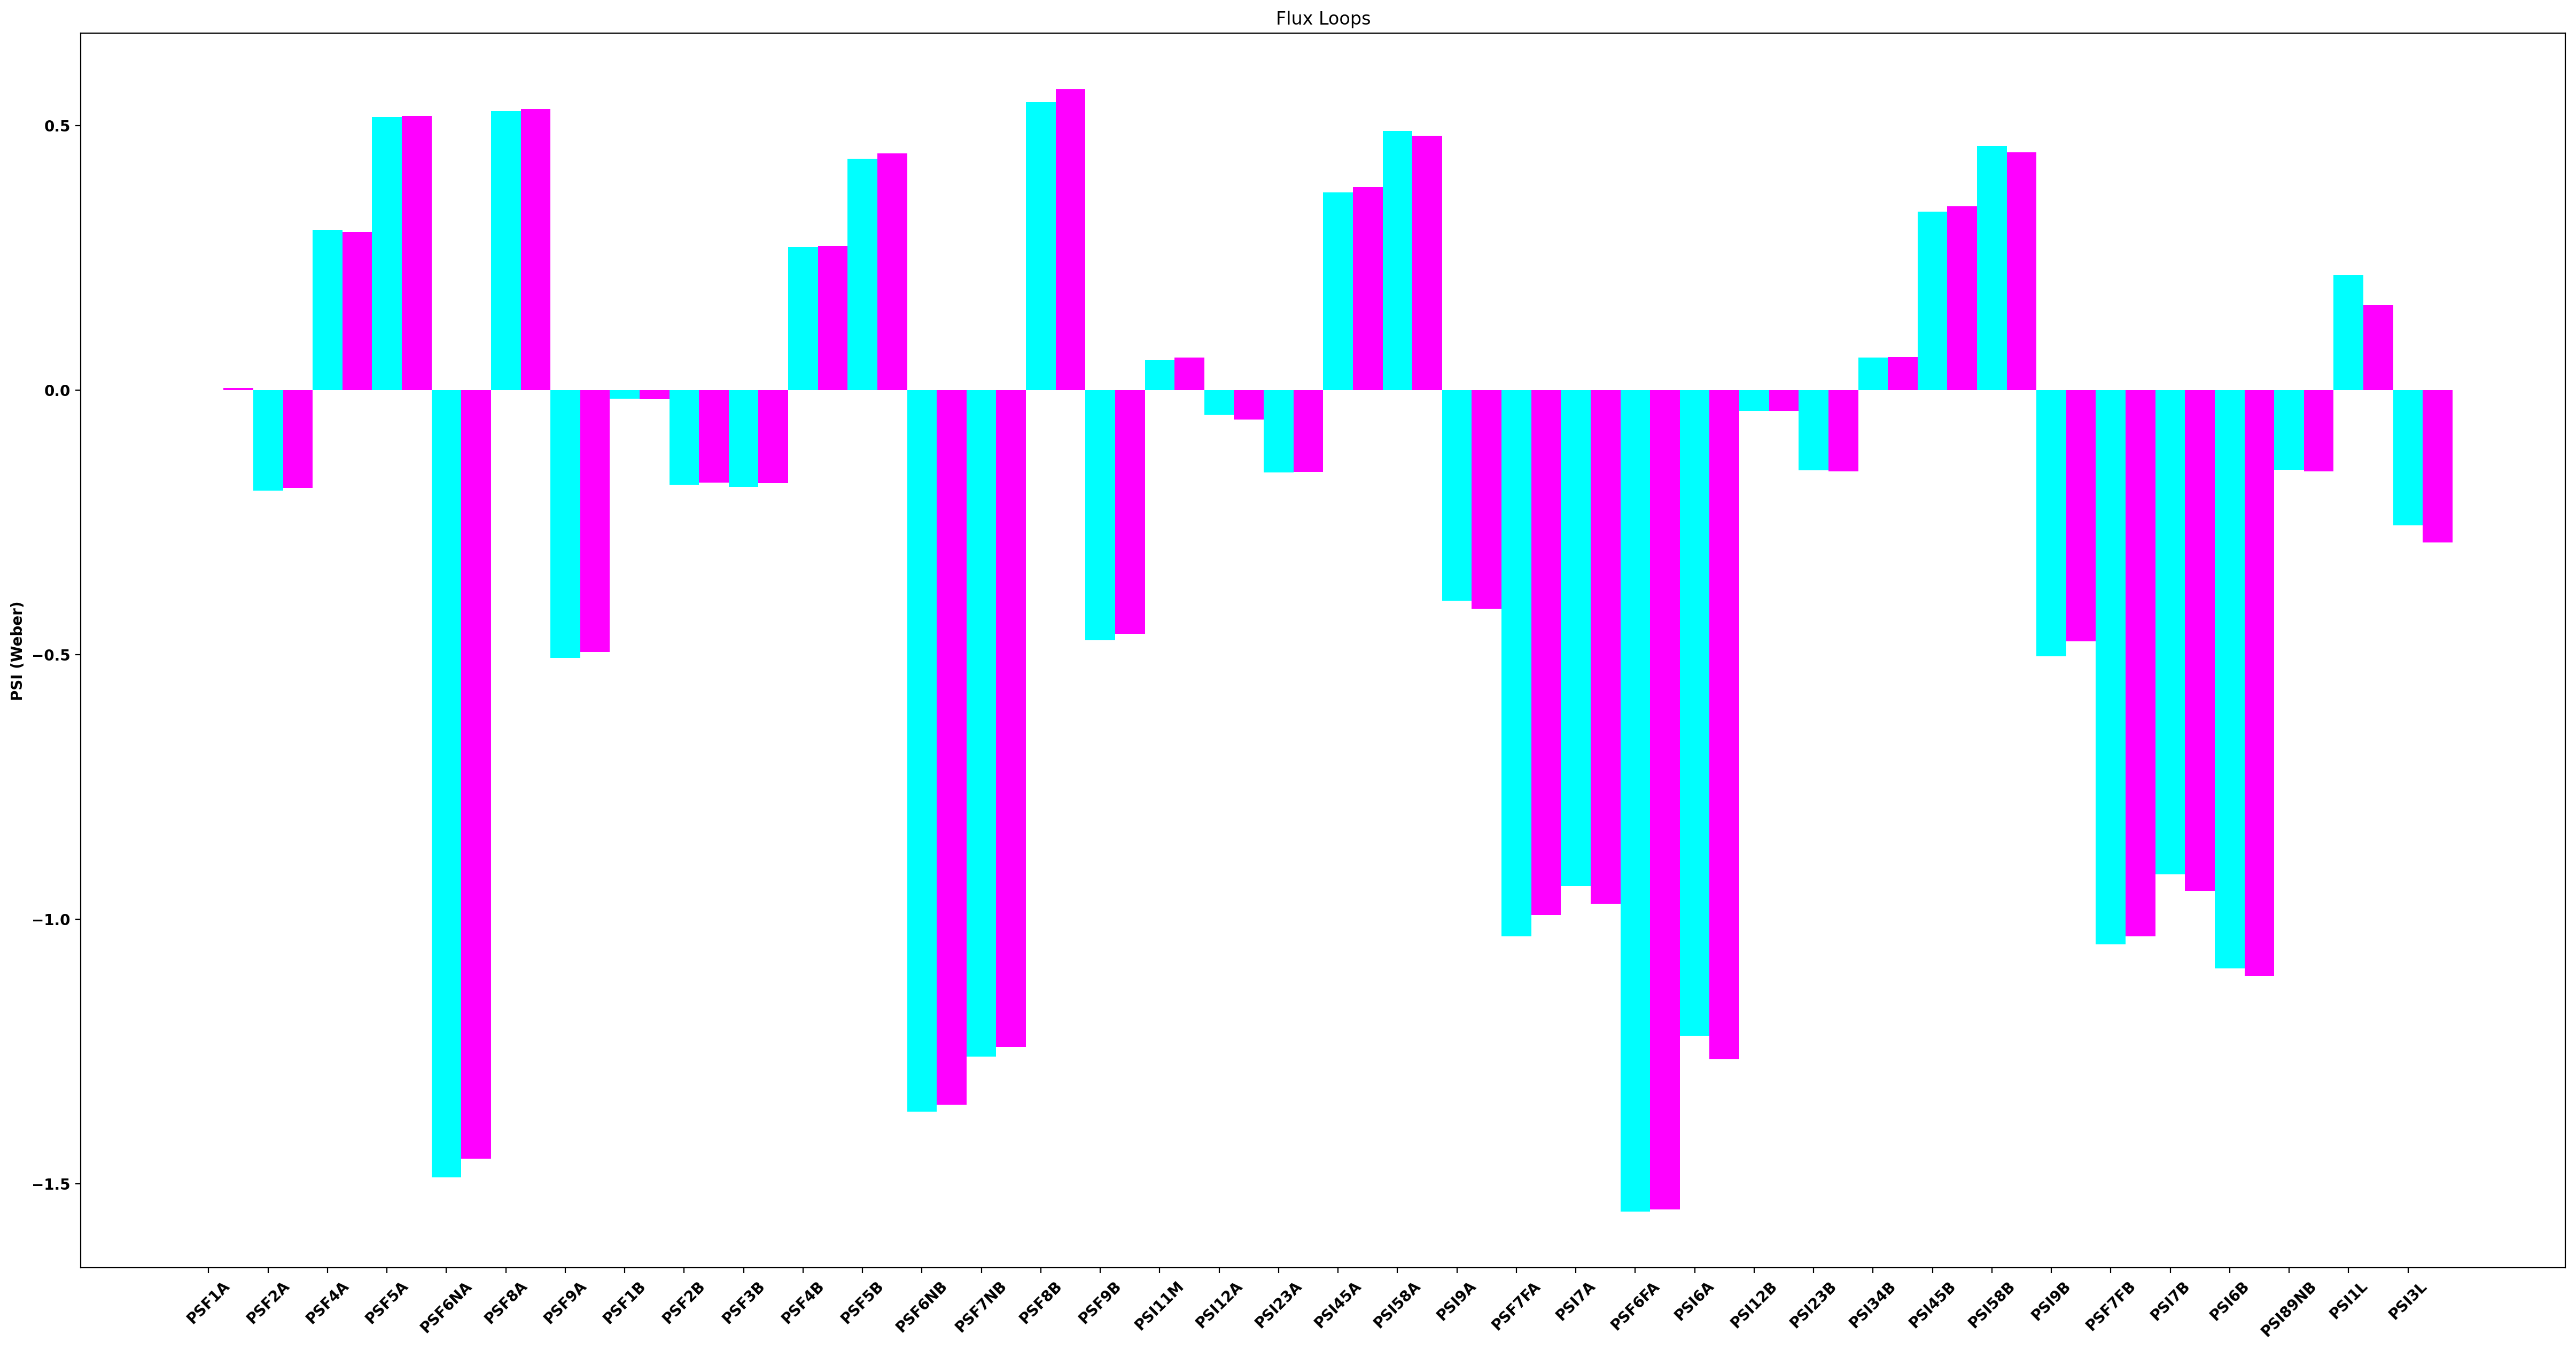

In [28]:
plot_flux()

## Get Strike Points

In [29]:
strike_pts = mygs.get_strike_points()

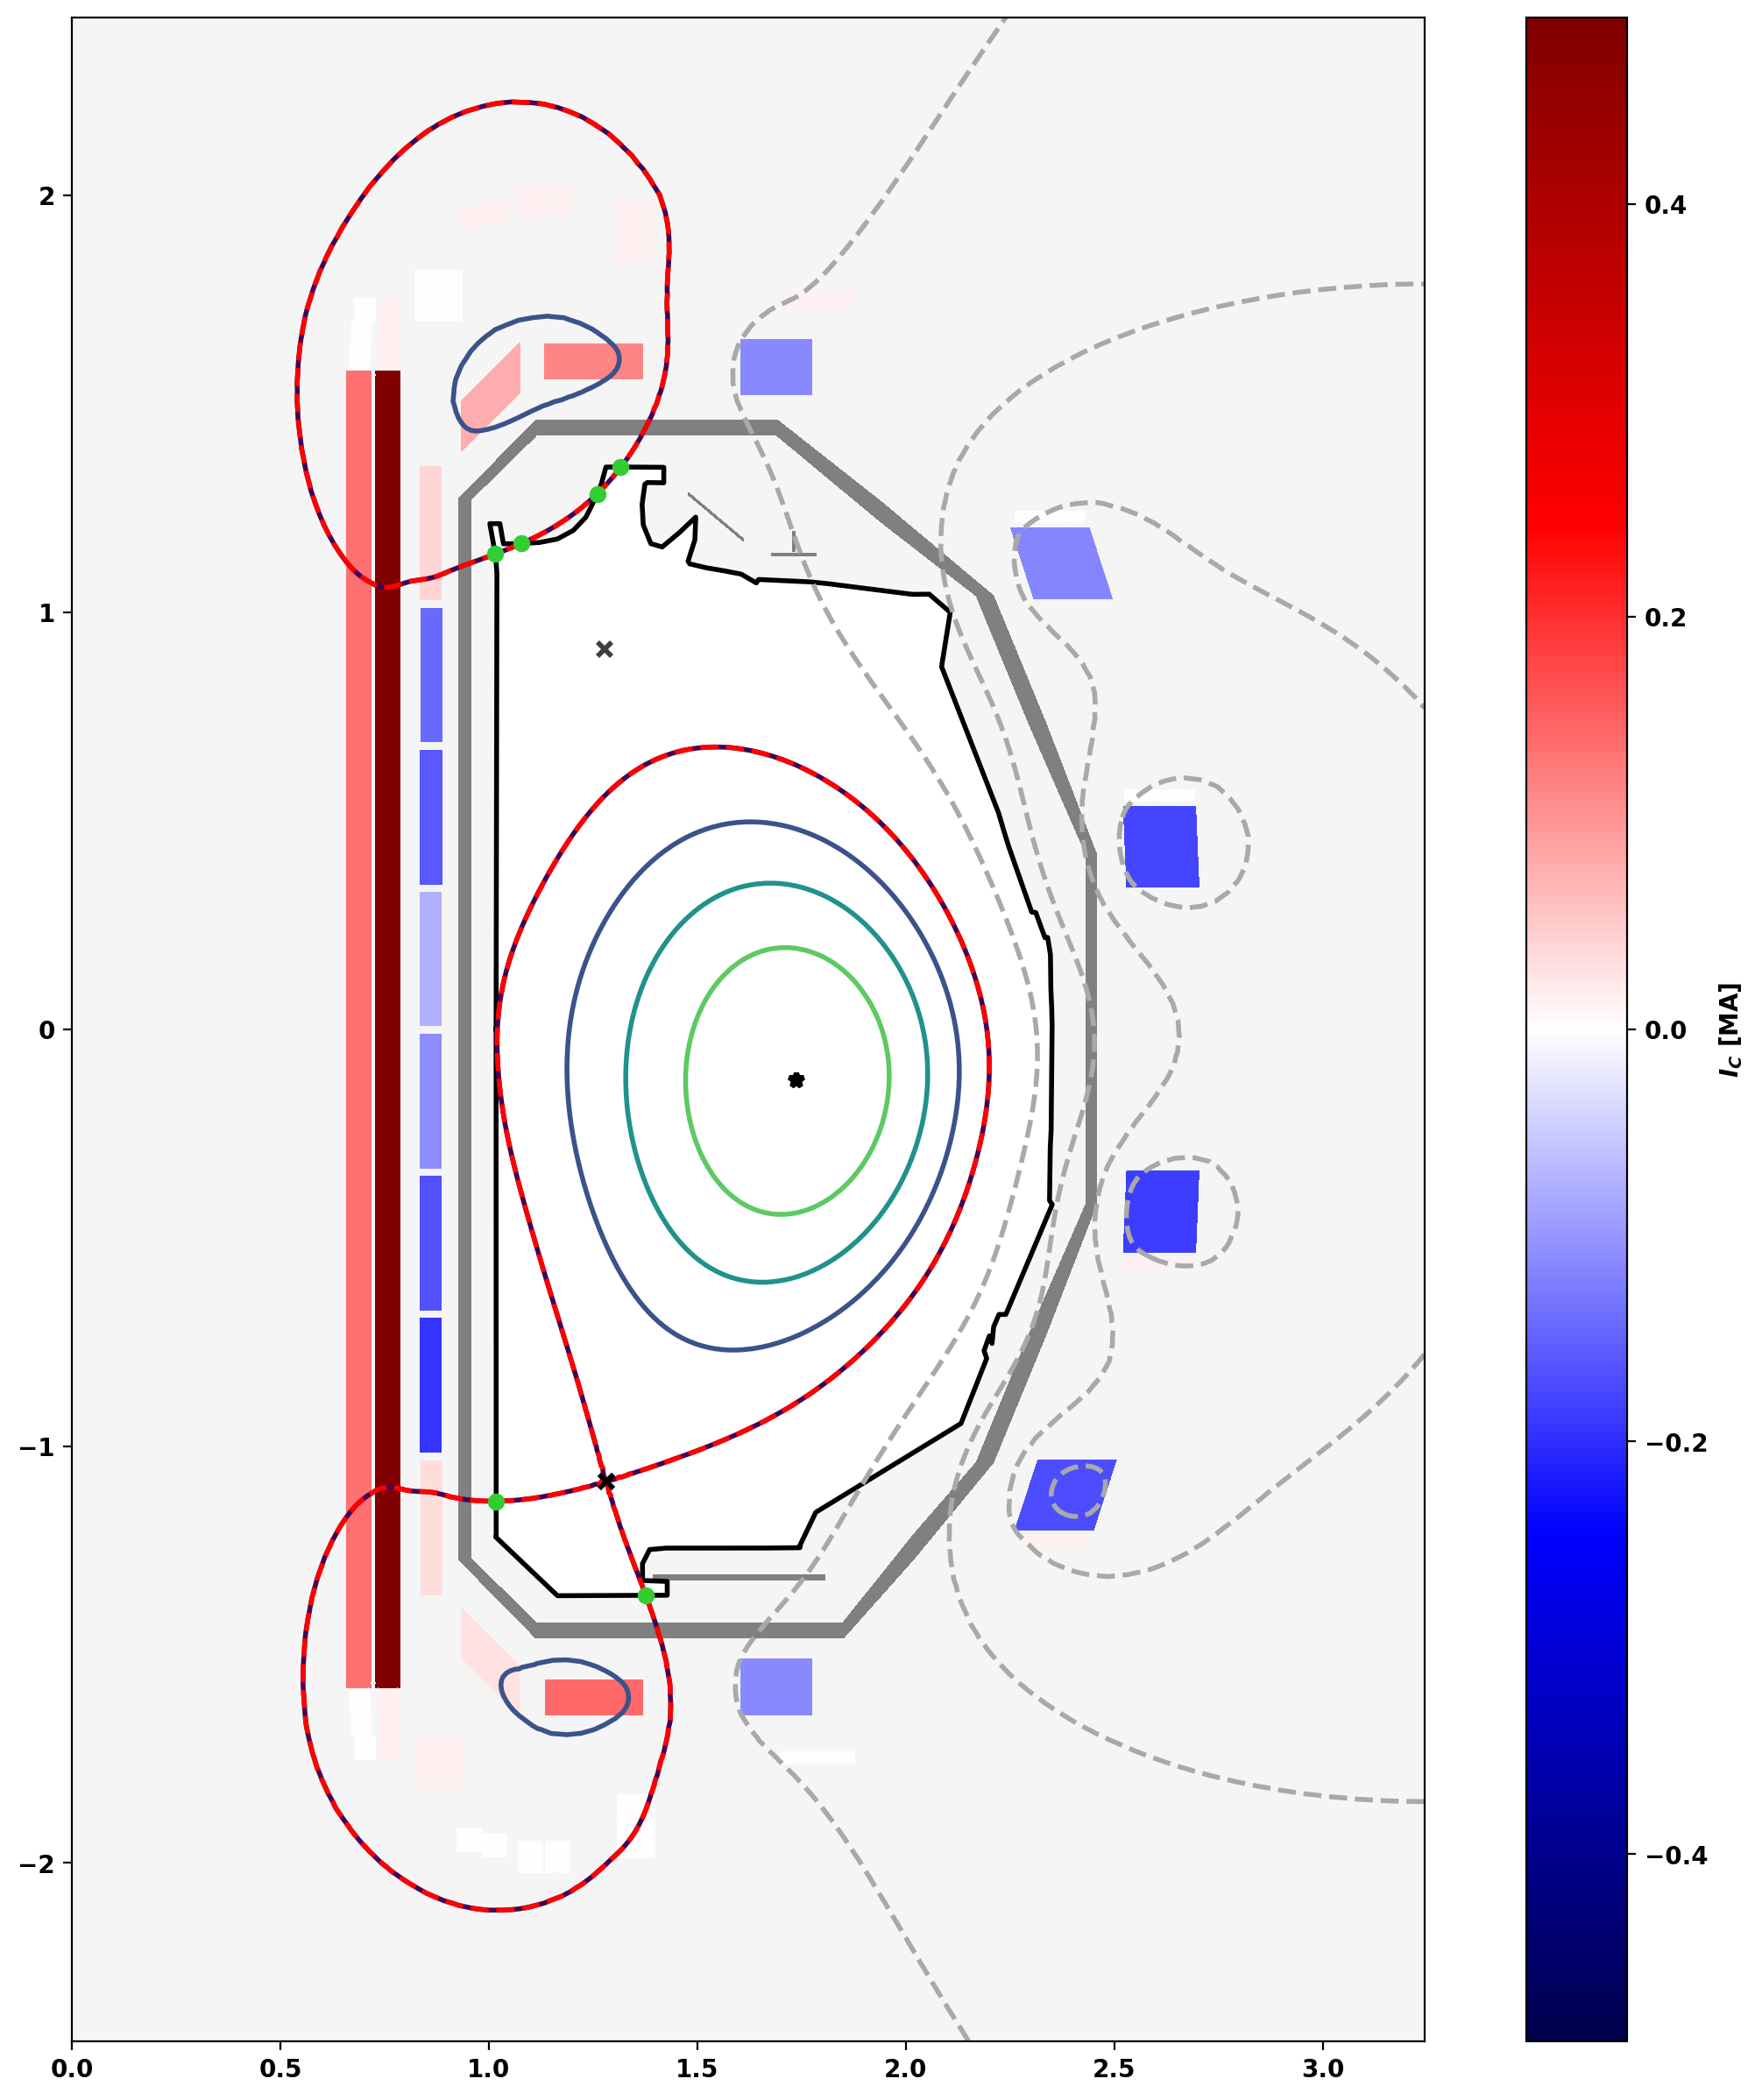

In [30]:
# Plot Psi
fig, ax = plt.subplots(1,1, figsize=(15,15))
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5)
mygs.plot_psi(fig,ax,psi=psi_eq,plasma_levels=[1.0,],plasma_color='red',vacuum_nlevels=0,plasma_linestyles='dashed')

strike_pts_r = [sp[0] for sp in strike_pts]
strike_pts_z = [sp[1] for sp in strike_pts]
ax.scatter(strike_pts_r, strike_pts_z, color='limegreen', zorder=10)

plt.show()